# Holdout externo LAB019–LAB021 con `theta_full`

Este notebook ejecuta un **holdout de réplicas sin ajuste** sobre LAB019–LAB021.

## Protocolo congelado

- `t0 = 21/09/2026 17:00`, aplicación de levadura.
- La muestra 1, tomada después de la primera nutrición y antes del inóculo, inicializa el modelo en `t=0`.
- La primera nutrición (0.4 g FDA + 1 g SFX) ya está contenida en ese estado inicial y no se aplica otra vez.
- La segunda nutrición se aplica como un salto de N de 0.08 kg m$^{-3}$ en su hora ejecutada.
- La cinética usa los 17 parámetros de `theta_natural_full.csv`; LAB019–LAB021 no participan en ningún ajuste.
- La capa de CO2 usa los parámetros naturales `C_full_theta_refit`, calibrados antes de esta campaña.
- El escenario principal obtiene la activación de la **química predicha**. La activación basada en química observada se reporta aparte como diagnóstico condicionado.
- El pico operacional alrededor de `t0` se marca inválido con una regla raw congelada y 90 min de recuperación. No se interpola.

El holdout químico puntúa G+F, G, F, YAN, glicerol, etanol y, como capa secundaria congelada, piruvato, acetaldehído y acetato.
El etanol observado entra desde la columna `Etanol` del Excel offline (% v/v, 6 de 12 muestras), convertido a g/L con
`ETHANOL_G_L_PER_PERCENT_VV` = 7.8924 (densidad 0.78924 g/mL, convención del repositorio); con esa medición m1 se
inicializa E0, igual que en el pipeline histórico de los originales (cuyo ETANOL t=0 es 1.23-1.25 % v/v).
Las alícuotas de Alcolyzer de m12 se diluyeron, distinto por lote: LAB020 con 27.5 mL de vino + 10 mL de agua y
LAB021 con 32.5 mL de vino + 5 mL de agua (ambas a 37.5 mL); su etanol se corrige ×37.5/27.5 y ×37.5/32.5
respectivamente. Brix y densidad se midieron antes de diluir y no se corrigen. La biomasa inicial (X0, Xd0) proviene del m1 de Oculyze de cada réplica con la conversión homologada del repositorio (`MILLION_CELLS_ML_TO_KG_M3` = 0.03 kg m$^{-3}$ por millón de células mL$^{-1}$, 30 pg por célula); las observaciones químicas de Oculyze siguen fuera de las métricas.


In [1]:
from __future__ import annotations

import csv
import json
import math
import re
import sys
from dataclasses import replace
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
from IPython import get_ipython
_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("matplotlib", "inline")
import numpy as np
import openpyxl
import pandas as pd
from IPython.display import Markdown, display

ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "fermentation_model").exists())
FM = ROOT / "fermentation_model"
LAB2026 = FM / "laboratory_2026"
DATA_DIR = FM / "data" / "mem2026" / "LAB019-021"
RESULTS_DIR = LAB2026 / "results" / "lab019_021_theta_full_holdout"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

for path in (FM, LAB2026, FM / "pilot_2025"):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from shared import run_new_must_glycerol_estimability_doe as base
from shared import run_secondary_joint_campaign_doe as joint
from shared import run_secondary_v2_model_evaluation as secondary_v2
from laboratory_2026 import run_estimability_historical_by_medium as natural_loader
from laboratory_2026 import run_co2_matrix_cross_validation_2026 as co2_cross

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9.5})

LABS = ("LAB019", "LAB020", "LAB021")
FERMENTER = {"LAB019": "F1", "LAB020": "F2", "LAB021": "F3"}
MATCHED_ORIGINAL = {"LAB019": "LAB004", "LAB020": "LAB006", "LAB021": "LAB009"}
COLORS = {"LAB019": "#4c72b0", "LAB020": "#55a868", "LAB021": "#c44e52"}
T0 = pd.Timestamp("2026-09-21 17:00:00")
# Hora y dosis reales del segundo pulso: hoja Nutricion, no un valor heredado del ajuste histórico.
nutrition_wb = openpyxl.load_workbook(
    DATA_DIR / "Mediciones-Offline-LAB019-021.xlsx", read_only=True, data_only=True
)
pulse2_rows = [
    row for row in nutrition_wb["Nutricion"].iter_rows(min_row=2, values_only=True)
    if row[0] in LABS and row[2] == "Pulso 2"
]
nutrition_wb.close()
assert len(pulse2_rows) == len(LABS)
assert {row[0] for row in pulse2_rows} == set(LABS)
PULSE2_DT = {row[0]: pd.Timestamp(row[3]) for row in pulse2_rows}
PULSE2_H = {lab: (stamp - T0).total_seconds() / 3600.0 for lab, stamp in PULSE2_DT.items()}
pulse2_doses = {row[0]: float(row[4]) / 1000.0 for row in pulse2_rows}  # mg/L -> kg/m³
assert len(set(pulse2_doses.values())) == 1, "el modelo usa una dosis común para los tres lotes"
DELTA_N_KG_M3 = next(iter(pulse2_doses.values()))
GRID_H = 0.25
CO2_FACTOR_G_L_H_PER_SCCM = 44.0095 * 60.0 * 0.74 / (1000.0 * 24.16 * 2.0)
assert np.isclose(CO2_FACTOR_G_L_H_PER_SCCM, 0.0404391928807947)
print("ROOT:", ROOT)
print("t0:", T0, "| pulse 2 [h]:", PULSE2_H)

ROOT: D:\claud\Desktop\Universidad\Memoria\Model\pyomo-doe
t0: 2026-09-21 17:00:00 | pulse 2 [h]: {'LAB019': 64.33333333333333, 'LAB020': 71.66666666666667, 'LAB021': 47.5}


## Parámetros congelados y procedencia

In [2]:
THETA_FULL_PATH = LAB2026 / "results" / "estimability_historical_natural" / "theta_natural_full.csv"
THETA_AUX_PATH = LAB2026 / "results" / "final_operational_doe_v2" / "theta_final_operational_v2.csv"
CO2_PARAM_PATH = LAB2026 / "results" / "co2_matrix_cross_validation_2026_full_theta_sccm_corrected_no_lab010" / "three_state_co2_parameters.csv"

theta_table = pd.read_csv(THETA_FULL_PATH)
theta_full = dict(zip(theta_table["parameter"], theta_table["theta"].astype(float)))
assert set(base.FULL17) == set(theta_full), (set(base.FULL17) - set(theta_full), set(theta_full) - set(base.FULL17))

theta_aux = pd.read_csv(THETA_AUX_PATH, index_col=0).iloc[:, 0].astype(float).to_dict()
theta_model = {**theta_aux, **theta_full}  # theta_full siempre prevalece en la capa cinética

co2_parameter_table = pd.read_csv(CO2_PARAM_PATH)
co2_parameter_table = co2_parameter_table[
    co2_parameter_table["state"].eq("C_full_theta_refit")
    & co2_parameter_table["calibration_matrix"].eq("natural")
].copy()
co2_params = dict(zip(co2_parameter_table["parameter"], co2_parameter_table["estimate"].astype(float)))
assert set(co2_cross.PARAMETER_BOUNDS).issubset(co2_params)

theta_table.to_csv(RESULTS_DIR / "theta_full_used.csv", index=False)
co2_parameter_table.to_csv(RESULTS_DIR / "co2_parameters_used.csv", index=False)

protocol_lock = {
    "holdout_labs": list(LABS),
    "fit_performed": False,
    "t0": str(T0),
    "initial_sample": "m1 post-nutrition/pre-inoculation, assigned to model t=0",
    "theta_full": str(THETA_FULL_PATH.relative_to(ROOT)),
    "secondary_parameters": str(THETA_AUX_PATH.relative_to(ROOT)),
    "co2_parameters": "C_full_theta_refit/natural",
    "first_nutrition": "contained in m1; not replayed",
    "second_nitrogen_increment_kg_m3": DELTA_N_KG_M3,
    "co2_conversion_g_l_h_per_sccm_at_2L": CO2_FACTOR_G_L_H_PER_SCCM,
    "co2_initial_artifact_rule": "raw Hampel max(3.5*MAD_sigma, 0.5 SCCM), search [-0.5, 0.75] h, plus 90 min recovery",
    "primary_activation": "predicted G+F drop >=5 g/L or predicted E rise >=2 g/L",
    "conditional_activation": "observed chemistry bracket; diagnostic only",
    "initial_biomass": "X0 = Oculyze m1 Concentration x MILLION_CELLS_ML_TO_KG_M3 (0.03 kg/m3 per million cells/mL, 30 pg/cell); Xd0 = X0 x (1 - viability%); replaces inheritance from matched original",
    "ethanol": "observed column Etanol (Excel offline, % v/v) -> g/L via ETHANOL_G_L_PER_PERCENT_VV = 7.8924; E0 initialized from m1 (pipeline convention)",
    "ethanol_m12_dilution": "per-lab Alcolyzer aliquot diluted to 37.5 mL: LAB020 27.5 mL wine + 10 mL water (x15/11); LAB021 32.5 mL wine + 5 mL water (x15/13); Brix/density measured pre-dilution, uncorrected",
}
(RESULTS_DIR / "protocol_lock.json").write_text(json.dumps(protocol_lock, indent=2, ensure_ascii=False), encoding="utf-8")

display(theta_table)
display(co2_parameter_table[["parameter", "estimate", "active_bound"]])

,parameter,theta,source
0,mu0,0.078728,laboratory_2026\results\estimability_historica...
1,sN,8.751446,shared\results\new_must_glycerol_overnight_val...
2,qN,0.021080,laboratory_2026\results\estimability_historica...
3,qXG,0.081491,shared\results\new_must_glycerol_overnight_val...
4,qXF,0.070933,shared\results\new_must_glycerol_overnight_val...
5,betaG0,0.428878,laboratory_2026\results\estimability_historica...
6,sG,0.097455,shared\results\new_must_glycerol_overnight_val...
7,betaF0,3.440399,laboratory_2026\results\estimability_historica...
8,sF,0.178295,shared\results\new_must_glycerol_overnight_val...
9,qEG,1.712807,laboratory_2026\results\estimability_historica...


,parameter,estimate,active_bound
45,kCO2_release_h,0.278349,False
46,CO2sat_scale,2.498908,True
47,O2_qmax_mg_gdw_h,0.253137,False
48,O2_initial_scale,0.179606,False
49,pulse_t_rise_h,56.741847,False
50,pulse_activity_gain,0.250011,True
51,chem_activation_start_fraction,0.741575,False
52,chem_activation_duration_fraction,0.457773,False
53,matrix_gain,1.602222,False


## Señal del logger: CO2, temperatura y CO2 disuelto

Primera vista de la campaña. La temperatura del log se filtra en tres pasos robustos centrados (mediana por minuto, mediana móvil de 20 min y media móvil de 45 min) para eliminar spikes y la oscilación de banda del control sin desplazar la señal; el CO2 se grafica en su canal filtrado nativo (`flow_filt_sccm`). Con esa temperatura filtrada y la lectura Carbodoseur (`Vol_Residual_mL`, muestras 1-6 del Excel offline) se calcula el CO2 disuelto con la tabla digitalizada `Tabla_CO2_disuelto_carbodoseur_long.csv` (grilla 41-100 mL x 0-20 °C; interpolación bilineal). La temperatura Anton Paar del Excel se muestra solo como referencia: se sabe que mide mal y NO se usa en el cálculo. Lecturas fuera de la grilla o temperatura >20 °C (techo de la tabla) se recortan y se marcan.

El Carbodoseur informa CO₂ presente en el líquido, mientras el logger mide el que sale al gas. La muestra 1 es anterior a la inoculación y sirve de referencia para cambios posteriores; el inicio del flujo gaseoso no equivale necesariamente al inicio de producción. La tabla llega solo a 20 °C: los puntos recortados son orientativos.

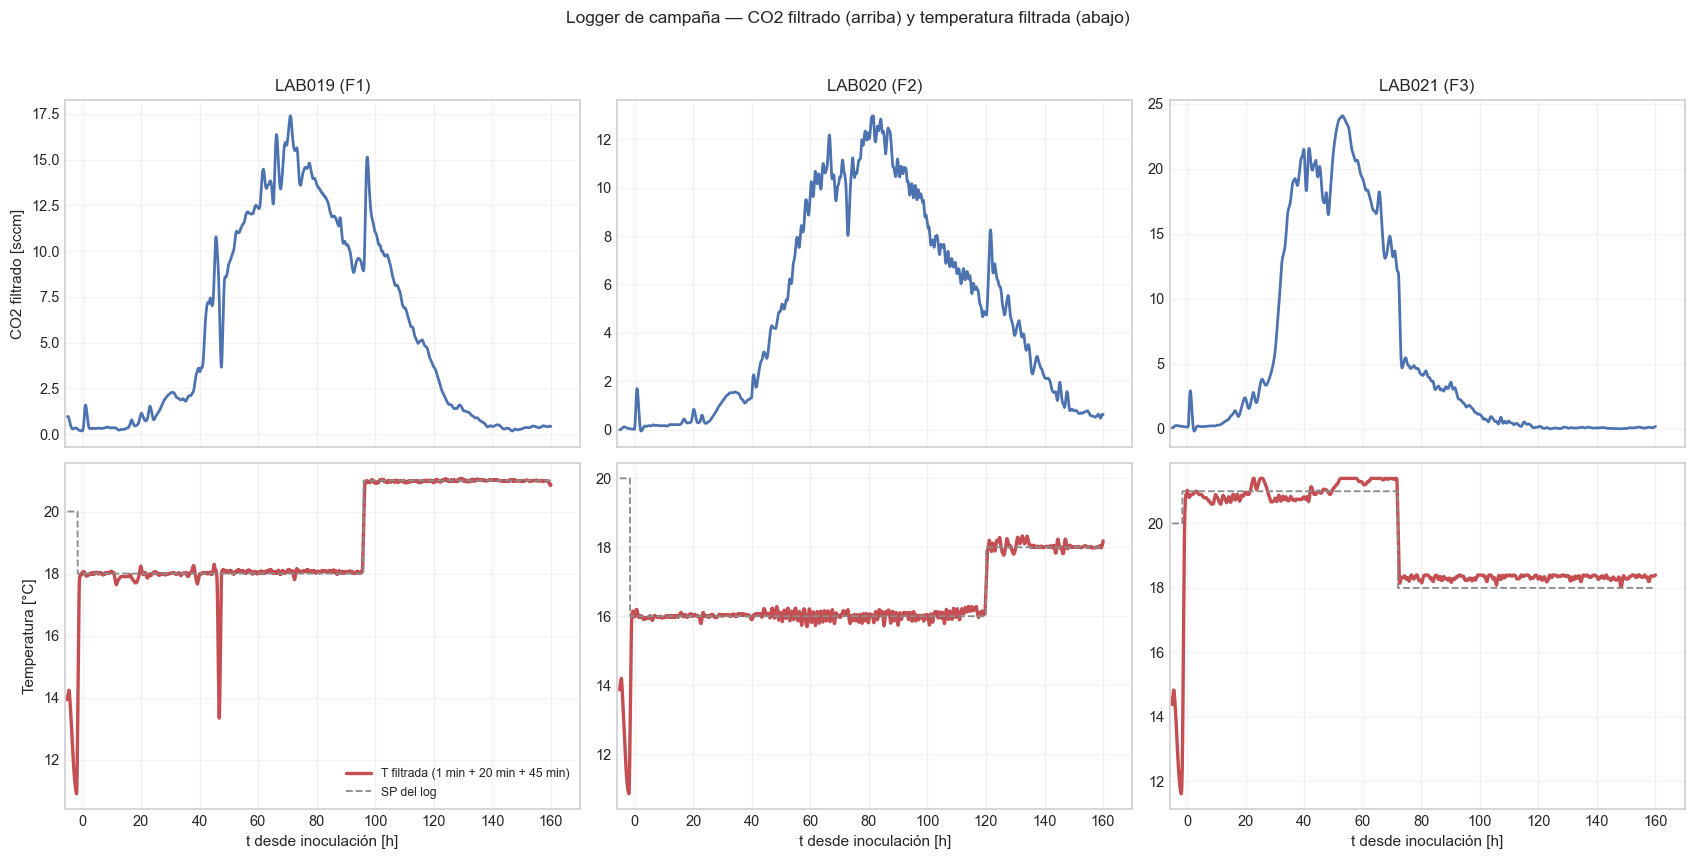

Filtrado de temperatura: mediana 1min -> mediana móvil 20min -> media móvil 45min (todas centradas, sin desplazamiento de fase).


In [3]:
def read_csv_window(path, usecols, start, end, chunksize=500_000):
    frames = []
    for chunk in pd.read_csv(path, usecols=usecols, chunksize=chunksize, low_memory=False):
        stamp = pd.to_datetime(chunk["timestamp"], errors="coerce")
        keep = stamp.between(start, end)
        if keep.any():
            part = chunk.loc[keep].copy()
            part["timestamp"] = stamp.loc[keep]
            frames.append(part)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(columns=usecols)


window_start, window_end = T0 - pd.Timedelta(hours=6), T0 + pd.Timedelta(hours=170)
temperature_raw = read_csv_window(
    DATA_DIR / "backup_global_temperatura.csv", ["timestamp", "fermentador", "T", "SP"], window_start, window_end
)
for col in ("T", "SP"):
    temperature_raw[col] = pd.to_numeric(temperature_raw[col], errors="coerce")
co2_raw = read_csv_window(
    DATA_DIR / "backup_global_co2.csv", ["timestamp", "fermentador", "flow_sccm", "flow_filt_sccm", "status"], window_start, window_end
)
for col in ("flow_sccm", "flow_filt_sccm"):
    co2_raw[col] = pd.to_numeric(co2_raw[col], errors="coerce")

TEMP_RESAMPLE = "1min"    # mediana por minuto: elimina outliers y uniformiza el cadence
TEMP_MEDIAN = "20min"     # mediana móvil: suprime ráfagas y spikes del control on/off
TEMP_MEAN = "45min"       # media móvil: suaviza la oscilación de banda del control

temp_log = {}
for _lab in LABS:
    _f = FERMENTER[_lab]
    frame = (temperature_raw[temperature_raw["fermentador"].eq(_f)]
             .dropna(subset=["T"]).sort_values("timestamp")
             .set_index("timestamp")[["T", "SP"]])
    frame = frame.resample(TEMP_RESAMPLE).median()
    t_med = frame["T"].rolling(TEMP_MEDIAN, center=True, min_periods=1).median()
    temp_log[_f] = pd.DataFrame({
        "T_filt": t_med.rolling(TEMP_MEAN, center=True, min_periods=1).mean(),
        "SP": frame["SP"],
    })

fig, axes = plt.subplots(2, 3, figsize=(15.5, 7.8), sharex=True)
for col, lab in enumerate(LABS):
    f = FERMENTER[lab]
    co2 = co2_raw[co2_raw["fermentador"].eq(f)].sort_values("timestamp")
    t_co2 = (co2["timestamp"] - T0).dt.total_seconds().to_numpy() / 3600.0
    step = max(1, len(co2) // 20000)
    ax = axes[0, col]
    ax.plot(t_co2[::step], co2["flow_filt_sccm"].to_numpy(float)[::step], color="#4c72b0", lw=1.8)
    ax.set_title(f"{lab} ({f})", fontsize=11)
    if col == 0:
        ax.set_ylabel("CO2 filtrado [sccm]", fontsize=10)
    ax = axes[1, col]
    tl = temp_log[f]
    t_temp = (tl.index - T0).total_seconds().to_numpy() / 3600.0
    ax.plot(t_temp, tl["T_filt"].to_numpy(float), color="#c44e52", lw=2.2, label="T filtrada (1 min + 20 min + 45 min)")
    ax.plot(t_temp, tl["SP"].to_numpy(float), color="0.55", lw=1.2, ls="--", label="SP del log")
    if col == 0:
        ax.set_ylabel("Temperatura [°C]", fontsize=10)
        ax.legend(fontsize=8, loc="lower right")
    ax.set_xlabel("t desde inoculación [h]", fontsize=10)
    for row in (0, 1):
        axes[row, col].grid(alpha=0.25)
        axes[row, col].set_xlim(-6.0, 170.0)
fig.suptitle("Logger de campaña — CO2 filtrado (arriba) y temperatura filtrada (abajo)", y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.97))
display(fig)
plt.close(fig)
print("Filtrado de temperatura: mediana", TEMP_RESAMPLE, "-> mediana móvil", TEMP_MEDIAN,
      "-> media móvil", TEMP_MEAN, "(todas centradas, sin desplazamiento de fase).")

Filas sin Fecha/Hora descartadas: 0; lecturas Carbodoseur: 18.


,lab,muestra,t_h,lectura_carbodoseur_mL,T_anton_paar_C_ref,T_log_filtrada_C,T_recortada_a_techo_tabla,CO2_disuelto_g_L
0,LAB019,1,-1.167,85.0,19.6,17.450,False,0.921
1,LAB020,1,-1.167,90.0,17.8,15.654,False,0.737
2,LAB021,1,-1.167,85.0,21.3,17.497,False,0.920
3,LAB019,2,16.000,71.0,19.8,17.953,False,1.439
4,LAB020,2,16.000,79.0,19.7,16.058,False,1.207
5,LAB021,2,16.000,60.0,20.7,20.854,True,1.710
6,LAB019,3,19.000,64.0,20.1,17.829,False,1.680
7,LAB020,3,19.000,79.0,19.0,16.059,False,1.207
8,LAB021,3,19.000,66.0,20.7,20.848,True,1.321
9,LAB019,4,22.000,54.0,20.8,17.892,False,1.988


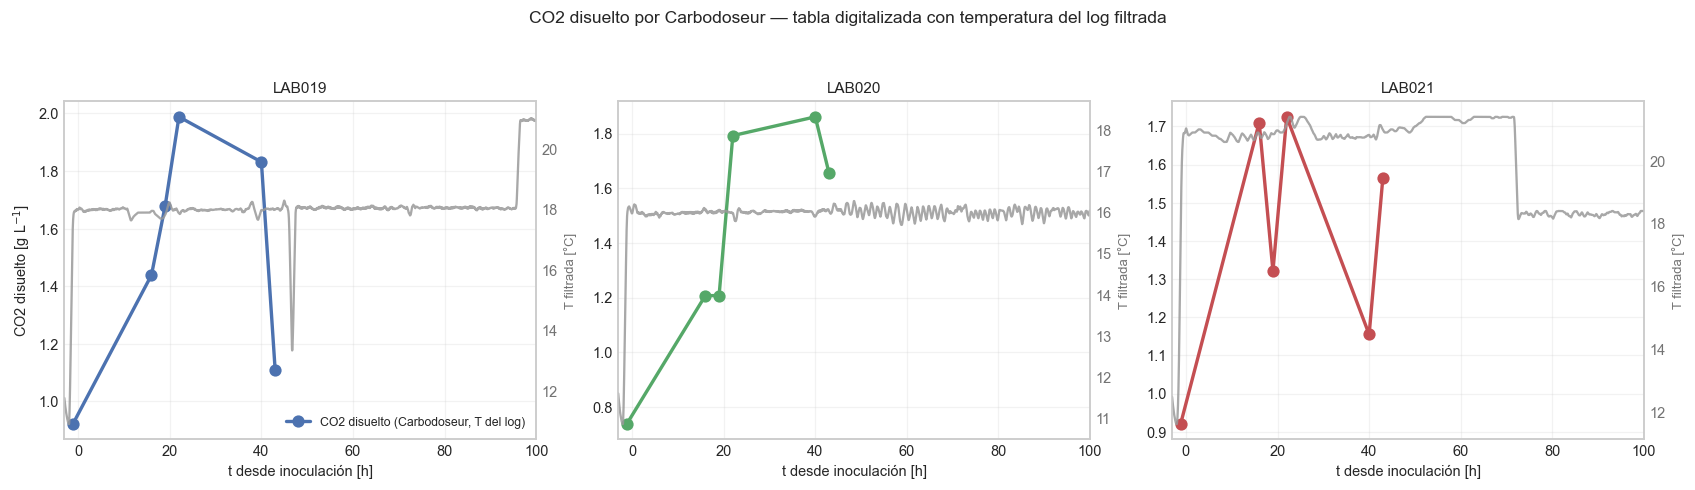

CO2 disuelto calculado: 18 lecturas; sin ajustes ni optimizaciones.


In [4]:
from scipy.interpolate import RegularGridInterpolator

CARBO_TABLE = DATA_DIR.parent / "Tabla_CO2_disuelto_carbodoseur_long.csv"
carbo_tabla = pd.read_csv(CARBO_TABLE)
piv = carbo_tabla.pivot_table(index="volumen_residual_mL", columns="temperatura_C", values="CO2_mg_L").sort_index()
vol_axis = piv.index.to_numpy(dtype=float)
temp_axis = piv.columns.to_numpy(dtype=float)
assert np.allclose(np.diff(vol_axis), 1.0) and np.allclose(np.diff(temp_axis), 1.0), "grilla de tabla no regular"
carbo_lookup = RegularGridInterpolator((vol_axis, temp_axis), piv.to_numpy(dtype=float),
                                       method="linear", bounds_error=False, fill_value=np.nan)

offline = pd.read_excel(DATA_DIR / "Mediciones-Offline-LAB019-021.xlsx", sheet_name="MedicionesOffline")
offline["muestra_num"] = pd.to_numeric(offline["Muestra"], errors="coerce")
offline = offline[offline["muestra_num"].notna()].copy()          # PI (pre-inóculo) queda fuera
offline["dt"] = pd.to_datetime(offline["Fecha"].astype(str) + " " + offline["Hora"].astype(str), errors="coerce")
n_sin_fecha = int(offline["dt"].isna().sum())
offline = offline.dropna(subset=["dt"])                            # descarta únicamente filas sin fecha/hora válida
offline["t_h"] = (offline["dt"] - T0).dt.total_seconds() / 3600.0

dissolved_rows = []
for r in offline.itertuples():
    tl = temp_log[r.Fermentador]
    t_arr = (tl.index - T0).total_seconds().to_numpy() / 3600.0
    t_log_c = float(np.interp(r.t_h, t_arr, tl["T_filt"].to_numpy(dtype=float)))
    t_used = float(np.clip(t_log_c, temp_axis[0], temp_axis[-1]))
    lectura = float(r.Vol_Residual_mL) if pd.notna(r.Vol_Residual_mL) else np.nan
    co2_mg_l = float(carbo_lookup(np.array([[lectura, t_used]]))[0]) if np.isfinite(lectura) else np.nan
    dissolved_rows.append({
        "lab": r.CodigoLab, "muestra": int(r.muestra_num), "t_h": float(r.t_h),
        "lectura_carbodoseur_mL": lectura,
        "T_anton_paar_C_ref": float(r.Temperatura_C) if pd.notna(r.Temperatura_C) else np.nan,
        "T_log_filtrada_C": t_log_c,
        "T_recortada_a_techo_tabla": bool(t_used != t_log_c),
        "CO2_disuelto_g_L": co2_mg_l / 1000.0 if np.isfinite(co2_mg_l) else np.nan,
    })
dissolved = pd.DataFrame(dissolved_rows)
dissolved.to_csv(RESULTS_DIR / "dissolved_co2_carbodoseur.csv", index=False)
print(f"Filas sin Fecha/Hora descartadas: {n_sin_fecha}; lecturas Carbodoseur: {dissolved['CO2_disuelto_g_L'].notna().sum()}.")
display(dissolved.round(3))

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4), sharex=True)
for ax, lab in zip(axes, LABS):
    sub = dissolved[dissolved["lab"].eq(lab)].sort_values("t_h")
    ok = sub["CO2_disuelto_g_L"].notna()
    ax.plot(sub.loc[ok, "t_h"], sub.loc[ok, "CO2_disuelto_g_L"], "o-", color=COLORS[lab], lw=2.2, ms=7,
            label="CO2 disuelto (Carbodoseur, T del log)")
    ax2 = ax.twinx()
    tl = temp_log[FERMENTER[lab]]
    t_arr = (tl.index - T0).total_seconds().to_numpy() / 3600.0
    ax2.plot(t_arr, tl["T_filt"].to_numpy(dtype=float), color="0.6", lw=1.5, alpha=0.85)
    ax2.set_ylabel("T filtrada [°C]", color="0.45", fontsize=8.5)
    ax2.tick_params(axis="y", labelcolor="0.45")
    ax2.grid(False)
    ax.set_title(lab, fontsize=10)
    ax.set_xlabel("t desde inoculación [h]")
    ax.grid(alpha=0.25)
    ax.set_xlim(-3.0, 100.0)
axes[0].set_ylabel("CO2 disuelto [g L$^{-1}$]")
axes[0].legend(fontsize=8, loc="lower right")
fig.suptitle("CO2 disuelto por Carbodoseur — tabla digitalizada con temperatura del log filtrada", y=1.0)
fig.tight_layout(rect=(0, 0, 1, 0.95))
display(fig)
plt.close(fig)
assert len(dissolved) == len(offline)
print(f"CO2 disuelto calculado: {dissolved['CO2_disuelto_g_L'].notna().sum()} lecturas; sin ajustes ni optimizaciones.")

,pareja,AUC_replica_ventana_comun_g_L,AUC_original_ventana_comun_g_L,AUC_replica_total_g_L,AUC_original_total_g_L,horizonte_replica_h,horizonte_original_h,ratio_replica_original_ventana_comun
0,LAB019 vs LAB004,35.47,30.82,35.47,30.91,160.0,190.0,1.15
1,LAB020 vs LAB006,31.62,21.31,31.62,22.73,160.0,213.0,1.48
2,LAB021 vs LAB009,36.15,8.95,36.15,8.98,160.0,161.0,4.04


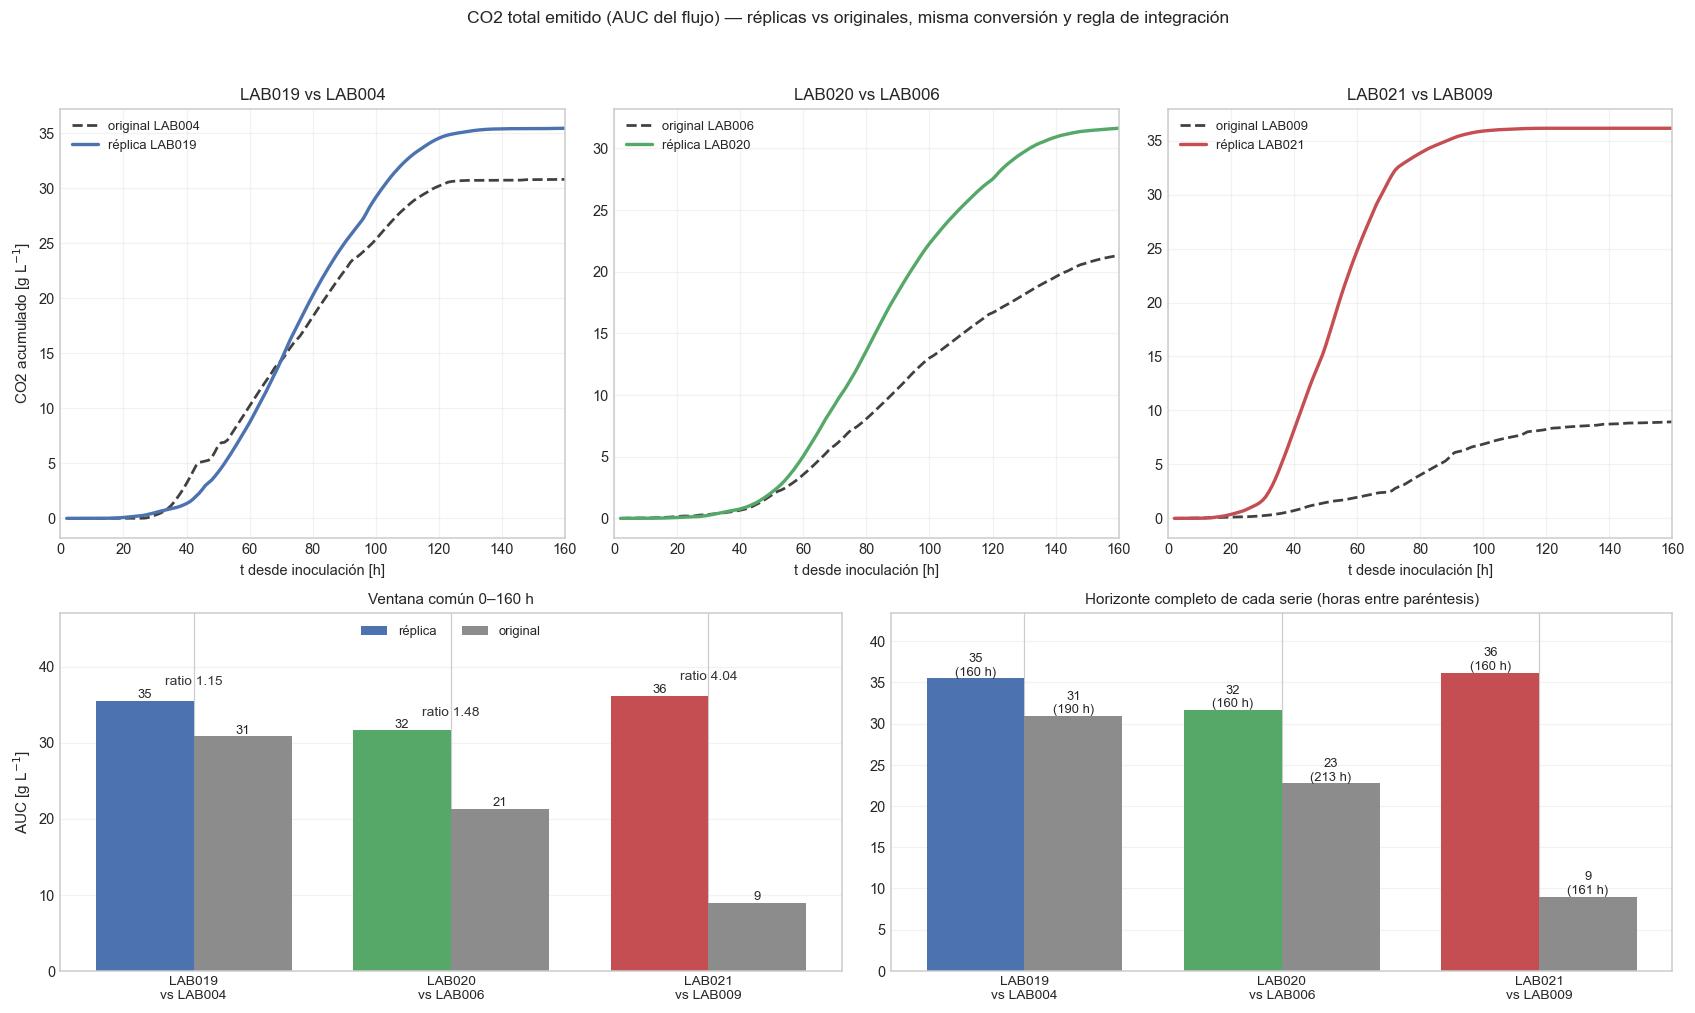

Regla de integración: inicio 2.5 h, cero p10 de [2.5, 12] h, mediana horaria, 0.0404 g/L/h por sccm.


In [5]:
# AUC del flujo de CO2 (CO2 total emitido): réplicas vs originales pareados.
# Regla simétrica para las seis señales: integración desde 2.5 h (cola de la máscara
# de agitación del arranque), cero del sensor = cuantil 10 % de [2.5, 12] h, mediana
# horaria, conversión documentada CO2_FACTOR_G_L_H_PER_SCCM = 0.0404 g L-1 h-1 / sccm.
# Los originales se cargan con el loader histórico (t0 del workbook, partes PT1/PT2,
# resample 10 min) y se reconvierten con la MISMA convención de las réplicas.
from laboratory_2026 import run_estimability_historical_by_medium as _hist

AUC_START_H, AUC_ZERO_END_H, AUC_COMMON_H = 2.5, 12.0, 160.0
PAIRS = [("LAB019", "LAB004"), ("LAB020", "LAB006"), ("LAB021", "LAB009")]


def hourly_rate_series(t_h, flow_sccm):
    df = pd.DataFrame({"t_h": np.asarray(t_h, float), "flow": np.asarray(flow_sccm, float)}).dropna()
    df = df[df["t_h"].ge(AUC_START_H)]
    if df.empty:
        return pd.DataFrame(columns=["t_h", "rate_g_l_h"])
    window = df.loc[df["t_h"].le(AUC_ZERO_END_H), "flow"]
    zero = max(float(window.quantile(0.10)), 0.0) if len(window) else 0.0
    df["rate_g_l_h"] = (df["flow"] - zero).clip(lower=0.0) * CO2_FACTOR_G_L_H_PER_SCCM
    hourly = df.groupby(np.floor(df["t_h"]).astype(int))["rate_g_l_h"].median().reset_index()
    hourly.columns = ["t_h", "rate_g_l_h"]
    return hourly


def cumulative(hourly):
    t = hourly["t_h"].to_numpy(float)
    y = hourly["rate_g_l_h"].to_numpy(float)
    cum = np.concatenate([[0.0], np.cumsum(0.5 * (y[1:] + y[:-1]) * np.diff(t))])
    return t, cum


def auc_total(hourly, t_max=None):
    d = hourly if t_max is None else hourly[hourly["t_h"].le(t_max)]
    if len(d) < 2:
        return np.nan
    return float(cumulative(d)[1][-1])


replica_series = {}
for lab in LABS:
    fr = co2_raw[co2_raw["fermentador"].eq(FERMENTER[lab])].dropna(subset=["flow_filt_sccm"]).copy()
    fr["t_h"] = (fr["timestamp"] - T0).dt.total_seconds() / 3600.0
    replica_series[lab] = hourly_rate_series(fr["t_h"], fr["flow_filt_sccm"])

original_series = {}
original_meta = _hist.load_natural_batch_metadata([orig for _, orig in PAIRS])
for lab, orig in PAIRS:
    meta_row = original_meta[original_meta["batch"].eq(orig)].iloc[0]
    parts = [_hist.read_process_file(r)[0] for r in _hist.discover_process_files(orig) if r["kind"] == "co2"]
    frame = pd.concat(parts, ignore_index=True)
    sampled = _hist.resample_process_signal(frame, "co2", meta_row["t0"], 400.0, float(meta_row["reactor_volume_l"]))
    original_series[lab] = hourly_rate_series(sampled["t_h"], sampled["flow_filt_sccm"])

auc_rows = []
for lab, orig in PAIRS:
    r, o = replica_series[lab], original_series[lab]
    auc_rows.append({
        "pareja": f"{lab} vs {orig}",
        "AUC_replica_ventana_comun_g_L": auc_total(r, AUC_COMMON_H),
        "AUC_original_ventana_comun_g_L": auc_total(o, AUC_COMMON_H),
        "AUC_replica_total_g_L": auc_total(r),
        "AUC_original_total_g_L": auc_total(o),
        "horizonte_replica_h": float(r["t_h"].max()) if len(r) else np.nan,
        "horizonte_original_h": float(o["t_h"].max()) if len(o) else np.nan,
    })
auc_table = pd.DataFrame(auc_rows)
auc_table["ratio_replica_original_ventana_comun"] = (
    auc_table["AUC_replica_ventana_comun_g_L"] / auc_table["AUC_original_ventana_comun_g_L"]
)
auc_table.to_csv(RESULTS_DIR / "co2_auc_replicas_vs_originals.csv", index=False)
display(auc_table.round(2))

fig = plt.figure(figsize=(15.5, 9.2))
gs = fig.add_gridspec(2, 6, height_ratios=(1.2, 1.0))
for k, (lab, orig) in enumerate(PAIRS):
    ax = fig.add_subplot(gs[0, 2 * k:2 * k + 2])
    t_o, c_o = cumulative(original_series[lab])
    t_r, c_r = cumulative(replica_series[lab])
    ax.plot(t_o, c_o, color="0.25", lw=1.8, ls="--", label=f"original {orig}")
    ax.plot(t_r, c_r, color=COLORS[lab], lw=2.2, label=f"réplica {lab}")
    ax.set_title(f"{lab} vs {orig}", fontsize=11)
    ax.set_xlabel("t desde inoculación [h]", fontsize=9.5)
    if k == 0:
        ax.set_ylabel("CO2 acumulado [g L$^{-1}$]", fontsize=10)
    ax.legend(fontsize=8.5, loc="upper left")
    ax.grid(alpha=0.25)
    ax.set_xlim(0.0, AUC_COMMON_H)

x = np.arange(len(PAIRS))
bar_w = 0.38
ax1 = fig.add_subplot(gs[1, 0:3])
rep_vals = auc_table["AUC_replica_ventana_comun_g_L"].to_numpy()
orig_vals = auc_table["AUC_original_ventana_comun_g_L"].to_numpy()
ax1.bar(x - bar_w / 2, rep_vals, bar_w, color=[COLORS[lab] for lab, _ in PAIRS], label="réplica")
ax1.bar(x + bar_w / 2, orig_vals, bar_w, color="0.55", label="original")
for xi, (rv, ov, ratio) in enumerate(zip(rep_vals, orig_vals, auc_table["ratio_replica_original_ventana_comun"])):
    ax1.text(xi - bar_w / 2, rv, f"{rv:.0f}", ha="center", va="bottom", fontsize=8.5)
    ax1.text(xi + bar_w / 2, ov, f"{ov:.0f}", ha="center", va="bottom", fontsize=8.5)
    ax1.text(xi, max(rv, ov) * 1.06, f"ratio {ratio:.2f}", ha="center", fontsize=9, color="0.2")
ax1.set_xticks(x, [f"{lab}\nvs {orig}" for lab, orig in PAIRS], fontsize=9)
ax1.set_ylabel("AUC [g L$^{-1}$]", fontsize=10)
ax1.set_title("Ventana común 0–160 h", fontsize=10)
ax1.set_ylim(0.0, max(rep_vals.max(), orig_vals.max()) * 1.30)
ax1.legend(fontsize=8.5, loc="upper center", ncol=2, frameon=False)
ax1.grid(alpha=0.25, axis="y")

ax2 = fig.add_subplot(gs[1, 3:])
rep_t = auc_table["AUC_replica_total_g_L"].to_numpy()
orig_t = auc_table["AUC_original_total_g_L"].to_numpy()
ax2.bar(x - bar_w / 2, rep_t, bar_w, color=[COLORS[lab] for lab, _ in PAIRS])
ax2.bar(x + bar_w / 2, orig_t, bar_w, color="0.55")
for xi, (rv, ov, hr, ho) in enumerate(zip(
    rep_t, orig_t, auc_table["horizonte_replica_h"], auc_table["horizonte_original_h"]
)):
    ax2.text(xi - bar_w / 2, rv, f"{rv:.0f}\n({hr:.0f} h)", ha="center", va="bottom", fontsize=8.5)
    ax2.text(xi + bar_w / 2, ov, f"{ov:.0f}\n({ho:.0f} h)", ha="center", va="bottom", fontsize=8.5)
ax2.set_xticks(x, [f"{lab}\nvs {orig}" for lab, orig in PAIRS], fontsize=9)
ax2.set_title("Horizonte completo de cada serie (horas entre paréntesis)", fontsize=10)
ax2.set_ylim(0.0, max(np.nanmax(rep_t), np.nanmax(orig_t)) * 1.20)
ax2.grid(alpha=0.25, axis="y")

fig.suptitle("CO2 total emitido (AUC del flujo) — réplicas vs originales, misma conversión y regla de integración", y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.965))
display(fig)
plt.close(fig)
print("Regla de integración: inicio 2.5 h, cero p10 de [2.5, 12] h, mediana horaria, 0.0404 g/L/h por sccm.")

## Carga química y control de calidad

In [6]:
from shared.new_must_data_loader import ETHANOL_G_L_PER_PERCENT_VV


def numeric(value):
    try:
        out = float(value)
        return out if np.isfinite(out) else np.nan
    except (TypeError, ValueError):
        return np.nan


def load_offline_samples():
    path = DATA_DIR / "Mediciones-Offline-LAB019-021.xlsx"
    wb = openpyxl.load_workbook(path, read_only=True, data_only=True)
    rows = []
    for excel_row, row in enumerate(wb["MedicionesOffline"].iter_rows(min_row=2, values_only=True), start=2):
        fecha, hora, lab, brix, density = row[0], row[1], row[2], row[5], row[6]
        if lab is None and brix is None and density is None:
            continue
        if lab not in LABS or fecha is None or hora is None or row[4] is None:
            raise ValueError(f"MedicionesOffline fila {excel_row}: metadatos de muestra incompletos")
        hh = hora.time() if isinstance(hora, datetime) else hora
        rows.append({
            "lab": str(lab), "sample": str(row[4]).strip(),
            "sample_timestamp": datetime.combine(fecha.date() if hasattr(fecha, "date") else fecha, hh),
            "Brix": numeric(brix), "density": numeric(density),
            "Etanol_pct_vv": numeric(row[10]), "metadata_fallback": False,
        })
    wb.close()
    result = pd.DataFrame(rows)
    assert not result.duplicated(["lab", "sample"]).any(), "muestras offline duplicadas"
    return result

def load_y15():
    rows = []
    paths = sorted(DATA_DIR.glob("EXPAuto*.txt")) + sorted(DATA_DIR.glob("ONLINE*.txt"))
    for path in paths:
        for line in open(path, encoding="utf-8-sig", errors="replace"):
            fields = line.rstrip("\n").split("\t")
            if len(fields) < 6:
                continue
            raw = fields[3].strip()
            value = float(raw.replace(",", ".")) if re.fullmatch(r"-?\d+(,\d+)?", raw) else np.nan
            rows.append({"sample_id": fields[0], "analyte": fields[1], "value": value, "raw_value": raw, "analysis_timestamp": fields[5], "source_file": path.name})
    long = pd.DataFrame(rows).drop_duplicates(["sample_id", "analyte"], keep="first")
    wide = long.pivot(index="sample_id", columns="analyte", values="value")
    raw_wide = long.pivot(index="sample_id", columns="analyte", values="raw_value")
    return long, wide, raw_wide


offline = load_offline_samples()
# Dilución Alcolyzer m12, distinta por lote (cuaderno de laboratorio): LAB020 27.5 mL de vino + 10 mL de agua;
# LAB021 32.5 mL de vino + 5 mL de agua (ambas a 37.5 mL). Sólo corrige etanol (medido en la mezcla);
# Brix y densidad se midieron antes de diluir.
DILUTION_FACTORS_M12 = {"LAB020": 37.5 / 27.5, "LAB021": 37.5 / 32.5}
for _lab_m12, _factor in DILUTION_FACTORS_M12.items():
    _sel = offline["lab"].eq(_lab_m12) & offline["sample"].eq("12")
    offline.loc[_sel, "Etanol_pct_vv"] = offline.loc[_sel, "Etanol_pct_vv"] * _factor
assert np.isclose(offline.loc[(offline["lab"] == "LAB020") & (offline["sample"] == "12"), "Etanol_pct_vv"].iloc[0], 7.33 * 15 / 11)
assert np.isclose(offline.loc[(offline["lab"] == "LAB021") & (offline["sample"] == "12"), "Etanol_pct_vv"].iloc[0], 8.66 * 15 / 13)
y15_long, y15, y15_raw = load_y15()

chem_rows = []
for lab in LABS:
    samples = offline[offline["lab"].eq(lab)].copy().set_index("sample")
    numbered_samples = sorted((item for item in samples.index if str(item).isdigit()), key=int)
    assert "1" in numbered_samples, f"{lab}: falta muestra inicial"
    for sample in numbered_samples:
        sid = f"{lab}-{sample}"
        meta = samples.loc[sample]
        stamp = pd.Timestamp(meta["sample_timestamp"])
        sample_t_h = (stamp - T0).total_seconds() / 3600.0
        t_h = 0.0 if sample == "1" else sample_t_h
        get = lambda name: float(y15.loc[sid, name]) if sid in y15.index and name in y15.columns and pd.notna(y15.loc[sid, name]) else np.nan
        get_raw = lambda name: str(y15_raw.loc[sid, name]) if sid in y15_raw.index and name in y15_raw.columns and pd.notna(y15_raw.loc[sid, name]) else ""
        gf_320_raw = get("GLU-FRU-320")
        gf_low_raw = get("GLUCOSE-FRUCTOSE")
        if np.isfinite(gf_320_raw) and gf_320_raw >= 0.0:
            gf, gf_source = gf_320_raw, "GLU-FRU-320"
        elif np.isfinite(gf_low_raw) and gf_low_raw >= 0.0:
            gf, gf_source = gf_low_raw, "GLUCOSE-FRUCTOSE"
        else:
            gf, gf_source = np.nan, ""
        glucose_320_raw = get("GLUCOSE-320")
        glucose_low_raw = get("GLUCOSE")
        glucose_raw = glucose_320_raw if np.isfinite(glucose_320_raw) else glucose_low_raw
        glucose = glucose_raw if np.isfinite(glucose_raw) and glucose_raw >= 0.0 else np.nan
        fructose = gf - glucose if np.isfinite(gf) and np.isfinite(glucose) and gf >= glucose else np.nan
        pan, ammonia_raw = get("PAN"), get("AMMONIA")
        ammonia = max(ammonia_raw, 0.0) if np.isfinite(ammonia_raw) else np.nan
        yan = pan + 0.823 * ammonia if np.isfinite(pan) and np.isfinite(ammonia) else np.nan
        chem_rows.append({
            "lab": lab, "sample": sample, "sample_timestamp": stamp, "sample_t_h": sample_t_h, "t_h": t_h,
            "metadata_fallback": bool(meta["metadata_fallback"]), "density": float(meta["density"]), "Brix": float(meta["Brix"]),
            "GF_g_l": gf, "GF_source": gf_source,
            "GF_320_raw_g_l": gf_320_raw, "GF_low_raw_g_l": gf_low_raw,
            "GF_320_below_zero": bool(np.isfinite(gf_320_raw) and gf_320_raw < 0.0),
            "G_g_l": glucose, "G_raw_g_l": glucose_raw, "F_g_l": fructose,
            "PAN_mg_l": pan, "NH3_raw_mg_l": ammonia_raw, "NH3_censored_mg_l": ammonia,
            "YAN_mg_l": yan, "N_kg_m3": yan / 1000.0 if np.isfinite(yan) else np.nan,
            "Gly_g_l": get("GLYCEROL"), "Pyr_mg_l": get("PYRUVIC ACID"),
            "Etanol_pct_vv": float(meta["Etanol_pct_vv"]),
            "E_g_l": meta["Etanol_pct_vv"] * ETHANOL_G_L_PER_PERCENT_VV if np.isfinite(meta["Etanol_pct_vv"]) else np.nan,
            "AcAld_mg_l": get("ACETALDEHID-1000"), "Acetate_g_l": get("ACETIC ACID"),
            "G_raw_text": get_raw("GLUCOSE-320") or get_raw("GLUCOSE"),
            "GF_raw_text": get_raw("GLU-FRU-320"),
            "GF_low_raw_text": get_raw("GLUCOSE-FRUCTOSE"),
            "NH3_below_zero": bool(np.isfinite(ammonia_raw) and ammonia_raw < 0.0),
        })
chem = pd.DataFrame(chem_rows).sort_values(["lab", "t_h"]).reset_index(drop=True)
chem["is_initial"] = chem["sample"].eq("1")
chem["soft_flag_GF"] = chem["lab"].eq("LAB019") & chem["sample"].eq("4")
chem["soft_flag_metadata"] = chem["metadata_fallback"]
chem["y15_available"] = chem[["GF_g_l", "YAN_mg_l", "Gly_g_l", "Pyr_mg_l", "AcAld_mg_l"]].notna().any(axis=1)
assert chem[chem["sample"].eq("1")]["E_g_l"].notna().all(), "falta Etanol m1 (inicializa E0)"

assert np.allclose(chem[chem["sample"].eq("1")]["t_h"], 0.0)
assert chem.query("lab == 'LAB020' and sample == '4'")["G_g_l"].isna().all()
assert chem.query("lab == 'LAB020' and sample == '4'")["G_raw_g_l"].iloc[0] == -7.28
assert chem[chem["sample"].eq("12")]["y15_available"].all(), "falta exportación Y15 m12"
assert chem.loc[chem["sample"].eq("12"), "GF_320_below_zero"].all(), "revisar QA de GF m12"
chem.to_csv(RESULTS_DIR / "chemistry_observations_qc.csv", index=False, encoding="utf-8-sig")
display(chem[["lab", "sample", "sample_t_h", "t_h", "GF_g_l", "G_g_l", "F_g_l", "YAN_mg_l", "Gly_g_l", "E_g_l", "Pyr_mg_l", "AcAld_mg_l", "y15_available", "NH3_below_zero", "metadata_fallback"]])
print("Muestras sin resultado Y15:", chem.loc[~chem["y15_available"], ["lab", "sample"]].to_dict("records"))

,lab,sample,sample_t_h,t_h,GF_g_l,G_g_l,F_g_l,YAN_mg_l,Gly_g_l,E_g_l,Pyr_mg_l,AcAld_mg_l,y15_available,NH3_below_zero,metadata_fallback
0,LAB019,1,-1.166667,0.0,158.16,79.19,78.97,260.025,1.22,12.075372,11.0,NaN,True,False,False
1,LAB019,2,16.000000,16.0,144.94,73.14,71.80,231.972,1.39,NaN,31.0,134.0,True,False,False
2,LAB019,3,19.000000,19.0,145.55,76.17,69.38,217.211,1.29,NaN,38.0,141.0,True,False,False
3,LAB019,4,22.000000,22.0,151.22,71.97,79.25,213.211,1.61,13.732776,43.0,168.0,True,False,False
4,LAB019,5,40.000000,40.0,136.87,NaN,NaN,160.114,2.46,NaN,92.0,235.0,True,False,False
5,LAB019,6,43.000000,43.0,129.50,NaN,NaN,129.831,2.82,NaN,95.0,327.0,True,False,False
6,LAB019,7,46.000000,46.0,127.72,NaN,NaN,108.194,2.75,18.231444,99.0,215.0,True,False,False
7,LAB019,8,64.000000,64.0,89.86,35.10,54.76,30.000,3.96,NaN,88.0,195.0,True,True,False
8,LAB019,9,67.500000,67.5,81.43,30.07,51.36,65.513,4.15,NaN,93.0,310.0,True,False,False
9,LAB019,10,70.500000,70.5,72.34,24.73,47.61,49.168,4.71,33.069156,79.0,288.0,True,False,False


Muestras sin resultado Y15: []


## Entradas operacionales y construcción de lotes

La biomasa inicial usa la concentración de Oculyze de la muestra 1 de cada réplica y la
misma conversión empírica de 0,03 kg m⁻³ por millón de células mL⁻¹ del pipeline histórico.
Se muestran también la alternativa con el control «CERO» restado y la biomasa del original
emparejado: ambas permiten auditar sensibilidad, pero ninguna cambia el holdout principal.
La muestra 1 se tomó 70 min antes de inocular; sus estados químicos se asignan a t=0 como
condición inicial. La temperatura proviene del sensor de cada fermentador.


In [7]:
historical_data = natural_loader.load_historical_medium_data("natural")
historical_batches = {b.batch: b for b in joint.make_secondary_batches(historical_data)}
historical_secondary_initials = joint.secondary_initials_by_medium(historical_data)["natural"]

def temperature_profile(lab, grid):
    f = FERMENTER[lab]
    frame = temperature_raw[temperature_raw["fermentador"].eq(f)].dropna(subset=["T"]).sort_values("timestamp")
    t = (frame["timestamp"] - T0).dt.total_seconds().to_numpy() / 3600.0
    return np.interp(grid, t, frame["T"].to_numpy(dtype=float))


holdout_batches = {}
core_predictions = {}
secondary_predictions = {}
initial_rows = []

# Biomasa inicial desde el m1 de Oculyze de cada réplica (~25 min tras la aplicación de
# levadura), con la misma conversión del pipeline histórico (30 pg/célula). La convención
# primaria es Concentración cruda x 0.03, idéntica a la que ancló las X de los originales
# (p.ej. LAB009 t=0: 12.04 x 0.03 = 0.361); la variante con CERO restado se reporta como referencia.
from shared.new_must_data_loader import MILLION_CELLS_ML_TO_KG_M3
assert abs(MILLION_CELLS_ML_TO_KG_M3 - 0.03) < 1e-12

def oculyze_m1_biomass(lab):
    with open(DATA_DIR / f"Oculyze_report_{lab}.csv", encoding="utf-8-sig") as handle:
        rows = list(csv.DictReader(handle))
    m1 = next(r for r in rows if r["Name"].strip().upper() == f"{lab}-1")
    cero = next((r for r in rows if r["Name"].strip().upper() == "CERO"), None)
    concentration = float(m1["Concentration"])
    viability = float(m1["Viability"])
    return {
        "x0_kg_m3": concentration * MILLION_CELLS_ML_TO_KG_M3,
        "xd0_kg_m3": concentration * MILLION_CELLS_ML_TO_KG_M3 * (1.0 - viability / 100.0),
        "oculyze_m1_concentration_mcells_ml": concentration,
        "oculyze_m1_viability_pct": viability,
        "x0_cero_subtracted_kg_m3": (
            max(concentration - float(cero["Concentration"]), 0.0) * MILLION_CELLS_ML_TO_KG_M3
            if cero is not None else float("nan")
        ),
    }

oculyze_biomass = {lab: oculyze_m1_biomass(lab) for lab in LABS}
for lab in LABS:
    c = chem[chem["lab"].eq(lab)].sort_values("t_h")
    init = c[c["sample"].eq("1")].iloc[0]
    original = historical_batches[MATCHED_ORIGINAL[lab]]
    f = FERMENTER[lab]
    co2_lab = co2_raw[co2_raw["fermentador"].eq(f)]
    logger_horizon = min(170.0, float((co2_lab["timestamp"].max() - T0).total_seconds() / 3600.0))
    measured_states = ["GF_g_l", "YAN_mg_l", "Gly_g_l", "E_g_l", "Pyr_mg_l", "AcAld_mg_l", "Acetate_g_l"]
    scored_chemistry = c[c[measured_states].notna().any(axis=1)]
    chemistry_horizon = float(scored_chemistry["t_h"].max())
    horizon = max(logger_horizon, chemistry_horizon)
    temp_lab = temperature_raw[temperature_raw["fermentador"].eq(f)].dropna(subset=["T"])
    temperature_last_h = float((temp_lab["timestamp"].max() - T0).total_seconds() / 3600.0)
    grid = np.arange(0.0, horizon + GRID_H / 2.0, GRID_H)
    grid = np.unique(np.r_[grid, c["t_h"].to_numpy(dtype=float), PULSE2_H[lab]])
    grid = grid[(grid >= 0.0) & (grid <= horizon + 1e-9)]
    temp = temperature_profile(lab, grid)
    # E0 desde el Etanol de m1 (% v/v -> g/L); los originales también inicializan E con su ETANOL t=0.
    initials = {
        "X": float(oculyze_biomass[lab]["x0_kg_m3"]), "Xd": float(oculyze_biomass[lab]["xd0_kg_m3"]),
        "N": float(init["N_kg_m3"]), "G": float(init["G_g_l"]), "F": float(init["F_g_l"]),
        "E": float(init["E_g_l"]), "Gly": float(init["Gly_g_l"]),
        "Pyr": float(init["Pyr_mg_l"]),
        "AcAld": float(historical_secondary_initials["AcAld"]),
        "Acetate": float(init["Acetate_g_l"]),
        "O2": float(historical_secondary_initials["O2"]), "CO2": 0.0,
    }
    observations = {state: np.full(len(grid), np.nan) for state in base.STATE_NAMES}
    observations.update({state: np.full(len(grid), np.nan) for state in ("Pyr", "AcAld", "Acetate", "O2")})
    # Química observada sólo se almacena para el diagnóstico condicionado; no altera la simulación cinética.
    for row in c.itertuples():
        idx = int(np.argmin(np.abs(grid - float(row.t_h))))
        if abs(grid[idx] - float(row.t_h)) > 1e-7:
            continue
        for state, value in (("G", row.G_g_l), ("F", row.F_g_l), ("N", row.N_kg_m3), ("Gly", row.Gly_g_l), ("E", row.E_g_l),
        ("Pyr", row.Pyr_mg_l), ("AcAld", row.AcAld_mg_l), ("Acetate", row.Acetate_g_l)):
            observations[state][idx] = value
    batch = base.BatchData(
        medium="natural", batch=lab, time=grid, temperature_c=temp,
        pulses={"N": ((PULSE2_H[lab], DELTA_N_KG_M3),), "G": tuple(), "F": tuple(), "E": tuple(), "X": tuple()},
        observations=observations, initials=initials,
    )
    core = base.simulate(batch, theta_full, grid)
    assert core is not None and np.isfinite(core.to_numpy()).all()
    secondary = secondary_v2.integrate_secondary_v2(batch, theta_model, core)
    assert np.isfinite(secondary.to_numpy()).all()
    holdout_batches[lab], core_predictions[lab], secondary_predictions[lab] = batch, core, secondary
    initial_rows.append({
        "lab": lab, "x0_source": f"Oculyze m1 {lab}-1", **oculyze_biomass[lab],
        "x0_heredado_del_original_kg_m3": float(original.initials["X"]),
        "matched_original_reference": MATCHED_ORIGINAL[lab],
        **initials, "horizon_h": horizon,
        "temperature_extrapolated_h": max(0.0, horizon - temperature_last_h),
    })

initial_table = pd.DataFrame(initial_rows)
initial_table.to_csv(RESULTS_DIR / "initial_conditions_used.csv", index=False)
display(initial_table)
if initial_table["temperature_extrapolated_h"].gt(0).any():
    print("AVISO: temperatura prolongada con el último valor medido hasta la última química; interpretar los puntos posteriores al logger como sensibilidad.")

,lab,x0_source,x0_kg_m3,xd0_kg_m3,oculyze_m1_concentration_mcells_ml,oculyze_m1_viability_pct,x0_cero_subtracted_kg_m3,x0_heredado_del_original_kg_m3,matched_original_reference,X,...,F,E,Gly,Pyr,AcAld,Acetate,O2,CO2,horizon_h,temperature_extrapolated_h
0,LAB019,Oculyze m1 LAB019-1,0.8595,0.029997,28.65,96.51,0.7707,0.3939,LAB004,0.8595,...,78.97,12.075372,1.22,11.0,26.0,0.15,1.41,0.0,166.0,5.955000
1,LAB020,Oculyze m1 LAB020-1,0.4113,0.004607,13.71,98.88,0.3432,0.0990,LAB006,0.4113,...,79.52,11.917524,1.38,8.0,26.0,0.17,1.41,0.0,166.0,5.954722
2,LAB021,Oculyze m1 LAB021-1,0.3999,0.018435,13.33,95.39,0.3399,0.3603,LAB009,0.3999,...,81.04,11.759676,1.28,7.0,26.0,0.16,1.41,0.0,166.0,5.954444


AVISO: temperatura prolongada con el último valor medido hasta la última química; interpretar los puntos posteriores al logger como sensibilidad.


## Holdout químico: predicciones y métricas

En m12 (166 h) el canal `GLU-FRU-320` informa valores negativos, que se conservan como QA pero no se ajustan como concentraciones. Se usa `GLUCOSE-FRUCTOSE` de rango bajo cuando es no negativo (LAB020 y LAB021); LAB019 queda sin punto G+F cuantitativo. La glucosa negativa también queda sin punto. Los demás analitos Y15 de m12 sí entran en las métricas. El logger de temperatura termina antes de 166 h; los valores predichos hasta m12 prolongan la última temperatura registrada, como indica la auditoría. El etanol (columna `Etanol` del Excel, % v/v → g/L ×7.8924) entra como variable de validación y en el bracket químico observado; E0 se inicializa con la m1. Las m12 de LAB020/LAB021 llevan corrección de dilución del Alcolyzer por lote (×37.5/27.5 y ×37.5/32.5); los valores corregidos (10.00 y 9.99 % v/v) son consistentes con LAB019 sin diluir (9.91).

In [8]:
CHEM_VARIABLES = {
    "GF": ("GF_g_l", "g/L"), "G": ("G_g_l", "g/L"), "F": ("F_g_l", "g/L"),
    "N": ("N_kg_m3", "kg/m3"), "Gly": ("Gly_g_l", "g/L"), "E": ("E_g_l", "g/L"),
    "Pyr": ("Pyr_mg_l", "mg/L"), "AcAld": ("AcAld_mg_l", "mg/L"), "Acetate": ("Acetate_g_l", "g/L"),
}

chem_prediction_rows = []
for lab in LABS:
    core, secondary = core_predictions[lab], secondary_predictions[lab]
    pulse_h = PULSE2_H[lab]
    for row in chem[chem["lab"].eq(lab)].itertuples():
        if row.sample == "1":
            continue  # condición inicial, no observación de validación
        t = float(row.t_h)
        predictions = {
            "GF": float(np.interp(t, core.index, core["G"] + core["F"])),
            "G": float(np.interp(t, core.index, core["G"])),
            "F": float(np.interp(t, core.index, core["F"])),
            "N": float(np.interp(t, core.index, core["N"])),
            "Gly": float(np.interp(t, core.index, core["Gly"])),
            "E": float(np.interp(t, core.index, core["E"])),
            "Pyr": float(np.interp(t, secondary.index, secondary["Pyr"])),
            "AcAld": float(np.interp(t, secondary.index, secondary["AcAld"])),
            "Acetate": float(np.interp(t, secondary.index, secondary["Acetate"])),
        }
        for variable, (column, unit) in CHEM_VARIABLES.items():
            observed = getattr(row, column)
            if not np.isfinite(observed):
                continue
            soft_flag = bool(row.soft_flag_metadata or (variable == "GF" and row.soft_flag_GF))
            chem_prediction_rows.append({
                "lab": lab, "sample": row.sample, "t_h": t,
                "domain": "pre_pulse2" if t < pulse_h else "post_pulse2",
                "variable": variable, "unit": unit, "observed": float(observed),
                "predicted": predictions[variable], "residual": predictions[variable] - float(observed),
                "soft_flag": soft_flag, "used_primary": True,
            })

chem_predictions = pd.DataFrame(chem_prediction_rows)
chem_predictions.to_csv(RESULTS_DIR / "chemistry_prediction_rows.csv", index=False)

def metric_table(rows, exclude_soft=False):
    data = rows[~rows["soft_flag"]].copy() if exclude_soft else rows.copy()
    data = pd.concat([data, data.assign(domain="full")], ignore_index=True)
    output = []
    for keys, group in data.groupby(["lab", "variable", "unit", "domain"], sort=True):
        error = group["predicted"].to_numpy() - group["observed"].to_numpy()
        obs = group["observed"].to_numpy()
        denom = np.sum((obs - obs.mean()) ** 2)
        output.append({
            "lab": keys[0], "variable": keys[1], "unit": keys[2], "domain": keys[3], "n": len(group),
            "MAE": float(np.mean(np.abs(error))), "RMSE": float(np.sqrt(np.mean(error**2))),
            "bias_pred_minus_obs": float(np.mean(error)),
            "R2": float(1.0 - np.sum(error**2) / denom) if denom > 0 else np.nan,
        })
    return pd.DataFrame(output)

chem_metrics = metric_table(chem_predictions, exclude_soft=False)
chem_metrics_sensitivity = metric_table(chem_predictions, exclude_soft=True)
chem_metrics.to_csv(RESULTS_DIR / "chemistry_metrics.csv", index=False)
chem_metrics_sensitivity.to_csv(RESULTS_DIR / "chemistry_metrics_excluding_soft_flags.csv", index=False)
display(chem_metrics[chem_metrics["domain"].eq("full")].round(4))

,lab,variable,unit,domain,n,MAE,RMSE,bias_pred_minus_obs,R2
0,LAB019,AcAld,mg/L,full,11,123.4502,140.9946,-123.4502,-3.0861
3,LAB019,Acetate,g/L,full,10,0.0672,0.0963,-0.0005,-0.8455
6,LAB019,E,g/L,full,5,19.2073,21.3226,19.2073,0.1668
9,LAB019,F,g/L,full,7,13.1011,15.4567,-13.1011,-0.0553
12,LAB019,G,g/L,full,7,14.7587,15.2420,-14.7587,0.6305
15,LAB019,GF,g/L,full,10,33.8580,35.9008,-33.8580,-0.0173
18,LAB019,Gly,g/L,full,11,1.2854,1.3148,1.2854,0.1581
21,LAB019,N,kg/m3,full,11,0.1013,0.1208,-0.1013,-1.4507
24,LAB019,Pyr,mg/L,full,11,36.0774,44.5984,-36.0740,-1.5152
27,LAB020,AcAld,mg/L,full,11,138.5081,154.4202,-138.5081,-3.3657


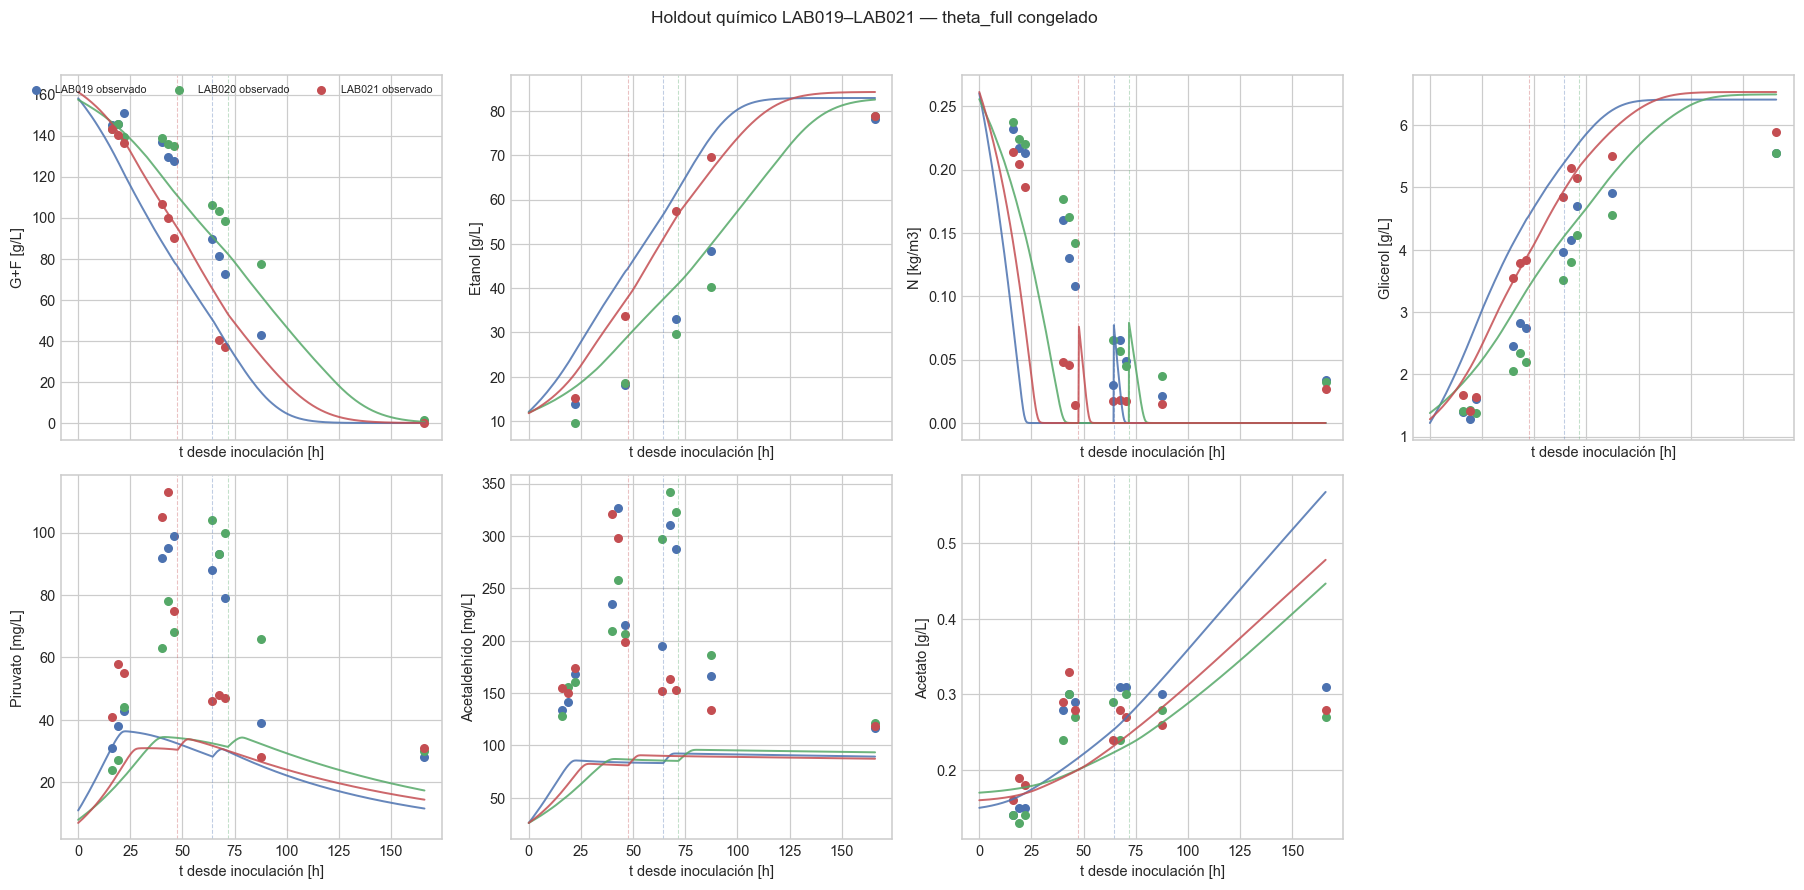

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(17, 8.2), sharex=True)
plot_variables = [("GF", "G+F [g/L]"), ("E", "Etanol [g/L]"), ("N", "N [kg/m3]"), ("Gly", "Glicerol [g/L]"), ("Pyr", "Piruvato [mg/L]"), ("AcAld", "Acetaldehído [mg/L]"), ("Acetate", "Acetato [g/L]")]
for ax, (variable, ylabel) in zip(axes.ravel(), plot_variables):
    for lab in LABS:
        rows = chem_predictions.query("lab == @lab and variable == @variable").sort_values("t_h")
        ax.scatter(rows["t_h"], rows["observed"], color=COLORS[lab], s=24, label=f"{lab} observado")
        if variable == "GF":
            pred = core_predictions[lab]["G"] + core_predictions[lab]["F"]
        elif variable == "E":
            pred = core_predictions[lab]["E"]
        elif variable in {"N", "Gly"}:
            pred = core_predictions[lab][variable]
        else:
            pred = secondary_predictions[lab][variable]
        ax.plot(pred.index, pred.values, color=COLORS[lab], lw=1.3, alpha=0.85)
        ax.axvline(PULSE2_H[lab], color=COLORS[lab], ls="--", lw=0.7, alpha=0.35)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("t desde inoculación [h]")
axes.ravel()[-1].axis("off")
axes[0, 0].legend(ncol=3, fontsize=7)
fig.suptitle("Holdout químico LAB019–LAB021 — theta_full congelado")
fig.tight_layout(rect=(0, 0, 1, 0.96))
display(fig)
plt.close(fig)

## CO2: máscara operacional, observaciones horarias y offset de cero

In [10]:
co2_hourly_parts, mask_rows = [], []
for lab in LABS:
    f = FERMENTER[lab]
    frame = co2_raw[co2_raw["fermentador"].eq(f)].sort_values("timestamp").copy()
    frame["t_h"] = (frame["timestamp"] - T0).dt.total_seconds() / 3600.0
    baseline = frame[frame["t_h"].between(-2.0, -0.5)]["flow_sccm"].dropna().to_numpy(dtype=float)
    baseline_center = float(np.median(baseline))
    sigma = float(1.4826 * np.median(np.abs(baseline - baseline_center)))
    threshold = max(3.5 * sigma, 0.5)
    search = frame[frame["t_h"].between(-0.5, 0.75)].copy()
    crossing = search[np.abs(search["flow_sccm"] - baseline_center) > threshold]
    if crossing.empty:
        event_start_h, event_raw_end_h = 0.0, 1.0
    else:
        event_start_h, event_raw_end_h = float(crossing["t_h"].min()), float(crossing["t_h"].max())
    mask_end_h = max(0.0, event_raw_end_h) + 1.5

    zero_support = frame[frame["t_h"].between(mask_end_h, 12.0)]["flow_filt_sccm"].dropna()
    zero_sccm = max(0.0, float(zero_support.quantile(0.10))) if len(zero_support) else 0.0
    frame["flow_corrected_sccm"] = np.maximum(frame["flow_filt_sccm"] - zero_sccm, 0.0)
    hourly = frame.set_index("timestamp")[["flow_corrected_sccm", "flow_filt_sccm", "flow_sccm"]].resample("1h").median().dropna(subset=["flow_corrected_sccm"]).reset_index()
    hourly["t_h"] = (hourly["timestamp"] - T0).dt.total_seconds() / 3600.0
    hourly = hourly[hourly["t_h"].between(0.0, 170.0)].copy()
    hourly["lab"] = lab
    hourly["co2_observed_g_l_h"] = hourly["flow_corrected_sccm"] * CO2_FACTOR_G_L_H_PER_SCCM
    hourly["co2_valid"] = hourly["t_h"] > mask_end_h
    hourly["left_censored"] = hourly["co2_observed_g_l_h"] < co2_cross.CO2_DETECTION_LIMIT_G_L_H
    co2_hourly_parts.append(hourly)
    mask_rows.append({
        "lab": lab, "fermenter": f, "baseline_raw_sccm": baseline_center, "baseline_sigma_sccm": sigma,
        "artifact_threshold_sccm": threshold, "event_start_h": event_start_h,
        "event_raw_end_h": event_raw_end_h, "recovery_tail_min": 90, "mask_end_h": mask_end_h,
        "sensor_zero_sccm": zero_sccm,
    })

co2_hourly = pd.concat(co2_hourly_parts, ignore_index=True)
mask_audit = pd.DataFrame(mask_rows)
co2_hourly.to_csv(RESULTS_DIR / "co2_hourly_observations.csv", index=False)
mask_audit.to_csv(RESULTS_DIR / "co2_mask_audit.csv", index=False)
display(mask_audit.round(4))

,lab,fermenter,baseline_raw_sccm,baseline_sigma_sccm,artifact_threshold_sccm,event_start_h,event_raw_end_h,recovery_tail_min,mask_end_h,sensor_zero_sccm
0,LAB019,F1,0.1689,0.0549,0.5,-0.1881,0.7475,90,2.2475,0.3005
1,LAB020,F2,0.0000,0.0000,0.5,-0.1825,0.6878,90,2.1878,0.1280
2,LAB021,F3,0.1483,0.0431,0.5,-0.1511,0.6878,90,2.1878,0.1436


## Capa de CO2 congelada

Se generan dos escenarios sin optimización:

1. **Primary end-to-end:** el bracket de activación se obtiene de G+F/E predichos con `theta_full`.
2. **Observed-chemistry conditioned:** usa el bracket observado y sólo diagnostica la capa de CO2.

El onset observado de CO2 nunca mueve ni alinea una predicción.


In [11]:
def activity_bracket(time_h, sugar, ethanol):
    time_h = np.asarray(time_h, dtype=float)
    sugar = np.asarray(sugar, dtype=float)
    ethanol = np.asarray(ethanol, dtype=float)
    valid = np.isfinite(sugar) | np.isfinite(ethanol)
    indices = np.flatnonzero(valid)
    if not len(indices):
        return {"lower_h": 0.0, "upper_h": 0.0, "center_h": 0.0, "scale_h": 1.0}
    s0 = sugar[np.isfinite(sugar)][0] if np.isfinite(sugar).any() else np.nan
    e0 = ethanol[np.isfinite(ethanol)][0] if np.isfinite(ethanol).any() else np.nan
    active = (np.isfinite(sugar) & (sugar <= s0 - 5.0)) | (np.isfinite(ethanol) & (ethanol >= e0 + 2.0))
    active_indices = np.flatnonzero(active)
    if len(active_indices):
        upper_i = int(active_indices[0])
        earlier = indices[indices < upper_i]
        lower_i = int(earlier[-1]) if len(earlier) else upper_i
        lower, upper = float(time_h[lower_i]), float(time_h[upper_i])
    else:
        lower = upper = float(time_h[indices[0]])
    return {"lower_h": lower, "upper_h": upper, "center_h": 0.5 * (lower + upper), "scale_h": max(1.0, (upper - lower) / (2.0 * math.log(9.0))) if upper > lower else 1.0}


co2_predictions = {}
activation_rows = []
for lab in LABS:
    batch = holdout_batches[lab]
    observed = co2_hourly[co2_hourly["lab"].eq(lab)].copy()
    horizon = float(observed["t_h"].max())
    stub = observed[["t_h"]].copy()
    stub["batch"] = lab
    stub["matrix"] = "natural"
    stub["calibratable"] = True
    stub["chemistry_last_h"] = horizon
    caches, _diag = co2_cross.build_driver_cache({lab: batch}, {"natural": theta_full}, stub)
    conditional_cache = caches[lab]

    core = core_predictions[lab]
    predicted_bracket = activity_bracket(core.index, core["G"] + core["F"], core["E"])
    c = chem[chem["lab"].eq(lab)].sort_values("t_h")
    observed_bracket = activity_bracket(c["t_h"], c["GF_g_l"], c["E_g_l"])
    primary_cache = replace(
        conditional_cache,
        chemical_activity_lower_h=predicted_bracket["lower_h"],
        chemical_activity_upper_h=predicted_bracket["upper_h"],
        chemical_activity_center_h=predicted_bracket["center_h"],
        chemical_activity_scale_h=predicted_bracket["scale_h"],
    )
    conditional_cache = replace(
        conditional_cache,
        chemical_activity_lower_h=observed_bracket["lower_h"],
        chemical_activity_upper_h=observed_bracket["upper_h"],
        chemical_activity_center_h=observed_bracket["center_h"],
        chemical_activity_scale_h=observed_bracket["scale_h"],
    )

    for scenario, cache, bracket in (
        ("primary_end_to_end", primary_cache, predicted_bracket),
        ("observed_chemistry_conditioned", conditional_cache, observed_bracket),
    ):
        qgas, qprod, o2, phi = co2_cross.raw_qgas_grid_prediction(
            cache,
            k_release_h=co2_params["kCO2_release_h"], sat_scale=co2_params["CO2sat_scale"],
            o2_qmax_mg_gdw_h=co2_params["O2_qmax_mg_gdw_h"], o2_initial_scale=co2_params["O2_initial_scale"],
            chemistry_aligned=True, nitrogen_boost_transition=True,
            pulse_t_rise_h=co2_params["pulse_t_rise_h"], pulse_activity_gain=co2_params["pulse_activity_gain"],
            continuous_release=True, bounded_chemical_activation=True,
            chem_activation_start_fraction=co2_params["chem_activation_start_fraction"],
            chem_activation_duration_fraction=co2_params["chem_activation_duration_fraction"],
        )
        co2_predictions[(scenario, lab)] = pd.DataFrame({
            "t_h": cache.time_h, "co2_predicted_g_l_h": co2_params["matrix_gain"] * qgas,
            "co2_produced_g_l_h": qprod, "O2_mg_l": o2, "anaerobic_fraction": phi,
        })
        activation_rows.append({"scenario": scenario, "lab": lab, **bracket})

activation_table = pd.DataFrame(activation_rows)
activation_table.to_csv(RESULTS_DIR / "activation_brackets.csv", index=False)
display(activation_table.round(3))

,scenario,lab,lower_h,upper_h,center_h,scale_h
0,primary_end_to_end,LAB019,3.75,4.00,3.875,1.000
1,observed_chemistry_conditioned,LAB019,0.00,16.00,8.000,3.641
2,primary_end_to_end,LAB020,8.00,8.25,8.125,1.000
3,observed_chemistry_conditioned,LAB020,0.00,16.00,8.000,3.641
4,primary_end_to_end,LAB021,6.25,6.50,6.375,1.000
5,observed_chemistry_conditioned,LAB021,0.00,16.00,8.000,3.641


In [12]:
def sustained_onset(time_h, values, threshold, consecutive=3):
    t, y = np.asarray(time_h, float), np.asarray(values, float)
    above = np.isfinite(y) & (y >= threshold)
    for i in range(0, len(y) - consecutive + 1):
        if above[i:i + consecutive].all():
            return float(t[i])
    return np.nan


prediction_rows, metric_rows = [], []
for lab in LABS:
    obs_all = co2_hourly[(co2_hourly["lab"].eq(lab)) & co2_hourly["co2_valid"]].sort_values("t_h").copy()
    early = obs_all[obs_all["t_h"].le(12.0)]
    baseline = float(early["co2_observed_g_l_h"].median()) if len(early) else 0.0
    peak = float(obs_all["co2_observed_g_l_h"].max())
    onset_threshold = max(co2_cross.CO2_DETECTION_LIMIT_G_L_H, baseline + 0.10 * max(peak - baseline, 0.0))
    for scenario in ("primary_end_to_end", "observed_chemistry_conditioned"):
        pred_curve = co2_predictions[(scenario, lab)]
        obs = obs_all.copy()
        obs["predicted"] = np.interp(obs["t_h"], pred_curve["t_h"], pred_curve["co2_predicted_g_l_h"])
        obs["scenario"] = scenario
        prediction_rows.append(obs[["scenario", "lab", "timestamp", "t_h", "co2_observed_g_l_h", "predicted", "left_censored"]])
        for domain, candidate in (
            ("pre_pulse2", obs["t_h"] < PULSE2_H[lab]),
            ("post_pulse2", obs["t_h"] >= PULSE2_H[lab]),
            ("full", np.ones(len(obs), dtype=bool)),
        ):
            part = obs[candidate].copy()
            if part.empty:
                continue
            error = part["predicted"].to_numpy() - part["co2_observed_g_l_h"].to_numpy()
            observed_values = part["co2_observed_g_l_h"].to_numpy()
            predicted_values = part["predicted"].to_numpy()
            times = part["t_h"].to_numpy()
            denom = np.sum((observed_values - observed_values.mean()) ** 2)
            dt = np.diff(times)
            pair_ok = (dt > 0) & (dt <= 1.5)
            auc_obs = float(np.sum(0.5 * (observed_values[:-1] + observed_values[1:]) * dt * pair_ok))
            auc_pred = float(np.sum(0.5 * (predicted_values[:-1] + predicted_values[1:]) * dt * pair_ok))
            onset_obs = sustained_onset(times, observed_values, onset_threshold)
            onset_pred = sustained_onset(times, predicted_values, onset_threshold)
            metric_rows.append({
                "scenario": scenario, "lab": lab, "domain": domain, "n": len(part),
                "MAE_g_l_h": float(np.mean(np.abs(error))), "RMSE_g_l_h": float(np.sqrt(np.mean(error**2))),
                "bias_pred_minus_obs_g_l_h": float(np.mean(error)),
                "R2": float(1.0 - np.sum(error**2) / denom) if denom > 0 else np.nan,
                "onset_threshold_g_l_h": onset_threshold, "onset_observed_h": onset_obs, "onset_predicted_h": onset_pred,
                "onset_error_h": onset_pred - onset_obs if np.isfinite(onset_obs) and np.isfinite(onset_pred) else np.nan,
                "peak_observed_g_l_h": float(observed_values.max()), "peak_predicted_g_l_h": float(predicted_values.max()),
                "peak_time_observed_h": float(times[np.argmax(observed_values)]), "peak_time_predicted_h": float(times[np.argmax(predicted_values)]),
                "AUC_observed_g_l": auc_obs, "AUC_predicted_g_l": auc_pred, "AUC_error_g_l": auc_pred - auc_obs,
            })

co2_prediction_rows = pd.concat(prediction_rows, ignore_index=True)
co2_metrics = pd.DataFrame(metric_rows)
co2_prediction_rows.to_csv(RESULTS_DIR / "co2_prediction_rows.csv", index=False)
co2_metrics.to_csv(RESULTS_DIR / "co2_metrics.csv", index=False)
display(co2_metrics[co2_metrics["domain"].eq("full")].round(4))

,scenario,lab,domain,n,MAE_g_l_h,RMSE_g_l_h,bias_pred_minus_obs_g_l_h,R2,onset_threshold_g_l_h,onset_observed_h,onset_predicted_h,onset_error_h,peak_observed_g_l_h,peak_predicted_g_l_h,peak_time_observed_h,peak_time_predicted_h,AUC_observed_g_l,AUC_predicted_g_l,AUC_error_g_l
2,primary_end_to_end,LAB019,full,158,0.1447,0.2159,0.0665,0.0163,0.0674,28.0,9.0,-19.0,0.6675,0.5760,71.0,34.0,35.4756,45.9851,10.5095
5,observed_chemistry_conditioned,LAB019,full,158,0.1136,0.1764,0.0351,0.3428,0.0674,28.0,19.0,-9.0,0.6675,0.5591,71.0,38.0,35.4756,41.0275,5.5519
8,primary_end_to_end,LAB020,full,158,0.0749,0.1099,0.0255,0.5639,0.0530,32.0,16.0,-16.0,0.5163,0.3796,81.0,55.0,31.6971,35.7229,4.0257
11,observed_chemistry_conditioned,LAB020,full,158,0.0674,0.1017,0.0176,0.6266,0.0530,32.0,21.0,-11.0,0.5163,0.3789,81.0,55.0,31.6971,34.4849,2.7877
14,primary_end_to_end,LAB021,full,158,0.1357,0.1774,0.0012,0.6837,0.0993,24.0,14.0,-10.0,0.9629,0.5122,53.0,42.0,36.2936,36.4813,0.1876
17,observed_chemistry_conditioned,LAB021,full,158,0.1256,0.1699,-0.0140,0.7100,0.0993,24.0,21.0,-3.0,0.9629,0.5077,53.0,42.0,36.2936,34.0759,-2.2177


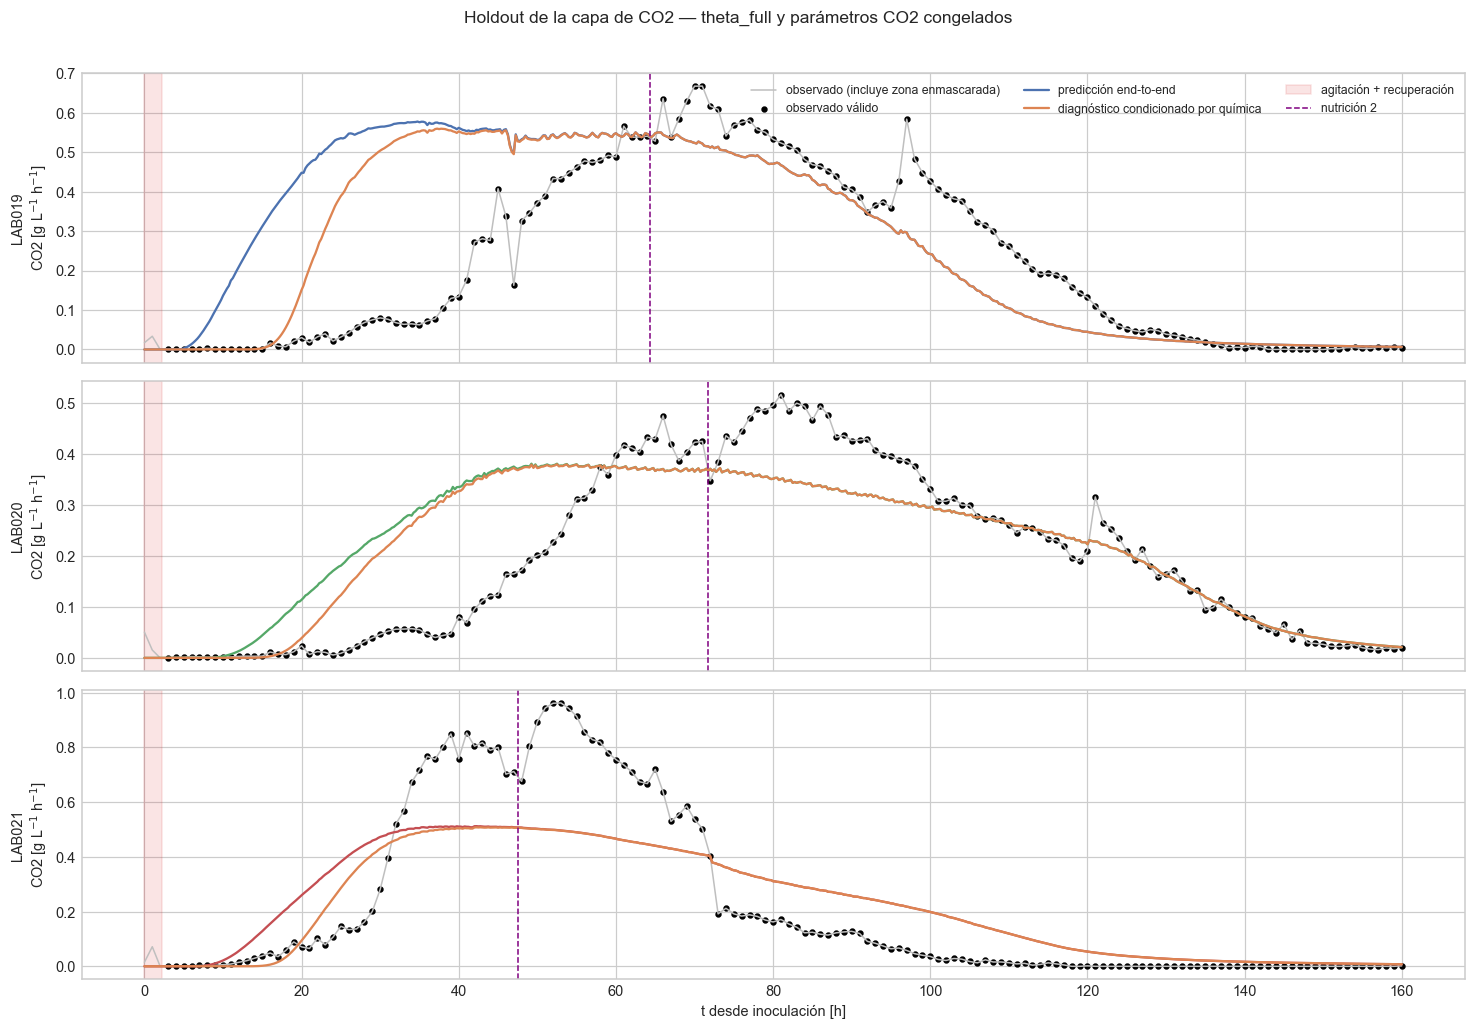

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(13.5, 9.5), sharex=True)
for ax, lab in zip(axes, LABS):
    all_obs = co2_hourly[co2_hourly["lab"].eq(lab)].sort_values("t_h")
    valid = all_obs["co2_valid"]
    ax.plot(all_obs["t_h"], all_obs["co2_observed_g_l_h"], color="0.75", lw=1.0, label="observado (incluye zona enmascarada)")
    ax.scatter(all_obs.loc[valid, "t_h"], all_obs.loc[valid, "co2_observed_g_l_h"], color="black", s=10, label="observado válido")
    for scenario, color, label in (
        ("primary_end_to_end", COLORS[lab], "predicción end-to-end"),
        ("observed_chemistry_conditioned", "#dd8452", "diagnóstico condicionado por química"),
    ):
        pred = co2_predictions[(scenario, lab)]
        ax.plot(pred["t_h"], pred["co2_predicted_g_l_h"], color=color, lw=1.5, label=label)
    mask_end = float(mask_audit.loc[mask_audit["lab"].eq(lab), "mask_end_h"].iloc[0])
    ax.axvspan(0.0, mask_end, color="#d62728", alpha=0.12, label="agitación + recuperación")
    ax.axvline(PULSE2_H[lab], color="purple", ls="--", lw=1.0, label="nutrición 2")
    ax.set_ylabel(f"{lab}\nCO2 [g L$^{{-1}}$ h$^{{-1}}$]")
axes[0].legend(ncol=3, fontsize=8)
axes[-1].set_xlabel("t desde inoculación [h]")
fig.suptitle("Holdout de la capa de CO2 — theta_full y parámetros CO2 congelados")
fig.tight_layout(rect=(0, 0, 1, 0.97))
display(fig)
plt.close(fig)

## Sensibilidad a la biomasa inicial (modelo congelado)

Se varía **solo** `X0`: la lectura Oculyze m1, esa lectura menos el blanco `CERO`, y el valor usado en el original emparejado como referencia. La última opción no representa una medición de la réplica. `theta_full`, temperatura, nutrientes y pulsos siguen congelados. El bracket se define por la primera caída predicha de 5 g/L de G+F o aumento de 2 g/L de etanol; es un umbral operativo, no el instante biológico exacto de inicio.

In [14]:
x0_sensitivity_rows = []
for lab in LABS:
    batch = holdout_batches[lab]
    baseline = core_predictions[lab]
    x0_cases = {
        'Oculyze m1 (principal)': float(batch.initials['X']),
        'Oculyze m1 menos CERO': float(oculyze_biomass[lab]['x0_cero_subtracted_kg_m3']),
        'original emparejado (referencia)': float(historical_batches[MATCHED_ORIGINAL[lab]].initials['X']),
    }
    for scenario, x0 in x0_cases.items():
        core = baseline if scenario == 'Oculyze m1 (principal)' else base.simulate(
            replace(batch, initials={**batch.initials, 'X': x0}), theta_full, batch.time
        )
        assert core is not None and np.isfinite(core.to_numpy()).all()
        bracket = activity_bracket(core.index, core['G'] + core['F'], core['E'])
        x0_sensitivity_rows.append({
            'lab': lab, 'scenario': scenario, 'X0_kg_m3': x0,
            'activation_center_h': bracket['center_h'],
            'GF_predicted_at_16h_g_l': float(np.interp(16.0, core.index, core['G'] + core['F'])),
        })
x0_sensitivity = pd.DataFrame(x0_sensitivity_rows)
x0_sensitivity.to_csv(RESULTS_DIR / 'x0_sensitivity_activation.csv', index=False)
display(x0_sensitivity.round(3))

,lab,scenario,X0_kg_m3,activation_center_h,GF_predicted_at_16h_g_l
0,LAB019,Oculyze m1 (principal),0.859,3.875,133.297
1,LAB019,Oculyze m1 menos CERO,0.771,4.125,135.665
2,LAB019,original emparejado (referencia),0.394,7.625,146.186
3,LAB020,Oculyze m1 (principal),0.411,8.125,146.641
4,LAB020,Oculyze m1 menos CERO,0.343,9.625,148.366
5,LAB020,original emparejado (referencia),0.099,25.375,154.762
6,LAB021,Oculyze m1 (principal),0.400,6.375,145.986
7,LAB021,Oculyze m1 menos CERO,0.340,7.375,148.169
8,LAB021,original emparejado (referencia),0.360,7.125,147.423


## Diagnóstico temprano: química, CO₂ emitido y CO₂ disuelto

La salida de gas es una observación posterior a la producción: primero se genera CO₂,
puede acumularse en el líquido y después sale por la línea del logger. Se compara la
química, la emisión acumulada hasta 16 y 22 h y el cambio de CO₂ disuelto respecto a la
muestra 1 anterior al inóculo.

La suma «gas emitido + cambio de CO₂ disuelto» es solo una aproximación: falta el CO₂ del
espacio de cabeza, puede haber pérdidas y la máscara inicial excluye una ventana del logger.
Asimismo, matrix_gain multiplica la predicción de gas, por lo que esa curva no constituye
por sí misma un balance de masa. La lectura Carbodoseur de LAB021 usa temperaturas recortadas
a 20 °C y tiene incertidumbre adicional. Este análisis no ajusta el modelo ni redefine
el onset para mejorar el holdout. El bracket químico observado [0, 16 h] solo acota el inicio:
no demuestra que la fermentación haya comenzado exactamente a las 16 h.


,lab,sample,t_h,GF_observed_g_l,GF_predicted_g_l,YAN_observed_mg_l,YAN_predicted_mg_l,CO2_gas_observed_g_l_lower_bound,CO2_gas_predicted_g_l,CO2_disuelto_muestra_g_l,CO2_disuelto_delta_vs_m1_g_l,CO2_gas_plus_delta_disuelto_g_l_proxy,temperature_clipped_at_20C
0,LAB019,2,16.0,144.94,133.297,231.972,79.653,0.018,1.734,1.439,0.518,0.536,False
1,LAB019,4,22.0,151.22,121.464,213.211,2.921,0.127,4.255,1.988,1.067,1.194,False
2,LAB020,2,16.0,143.11,146.641,237.795,184.705,0.032,0.150,1.207,0.470,0.503,False
3,LAB020,4,22.0,139.08,141.401,219.857,148.601,0.101,0.750,1.793,1.056,1.156,False
4,LAB021,2,16.0,143.02,145.986,214.211,144.486,0.158,0.513,1.710,0.790,0.948,True
5,LAB021,4,22.0,136.52,137.394,186.220,75.840,0.552,1.914,1.725,0.805,1.357,True


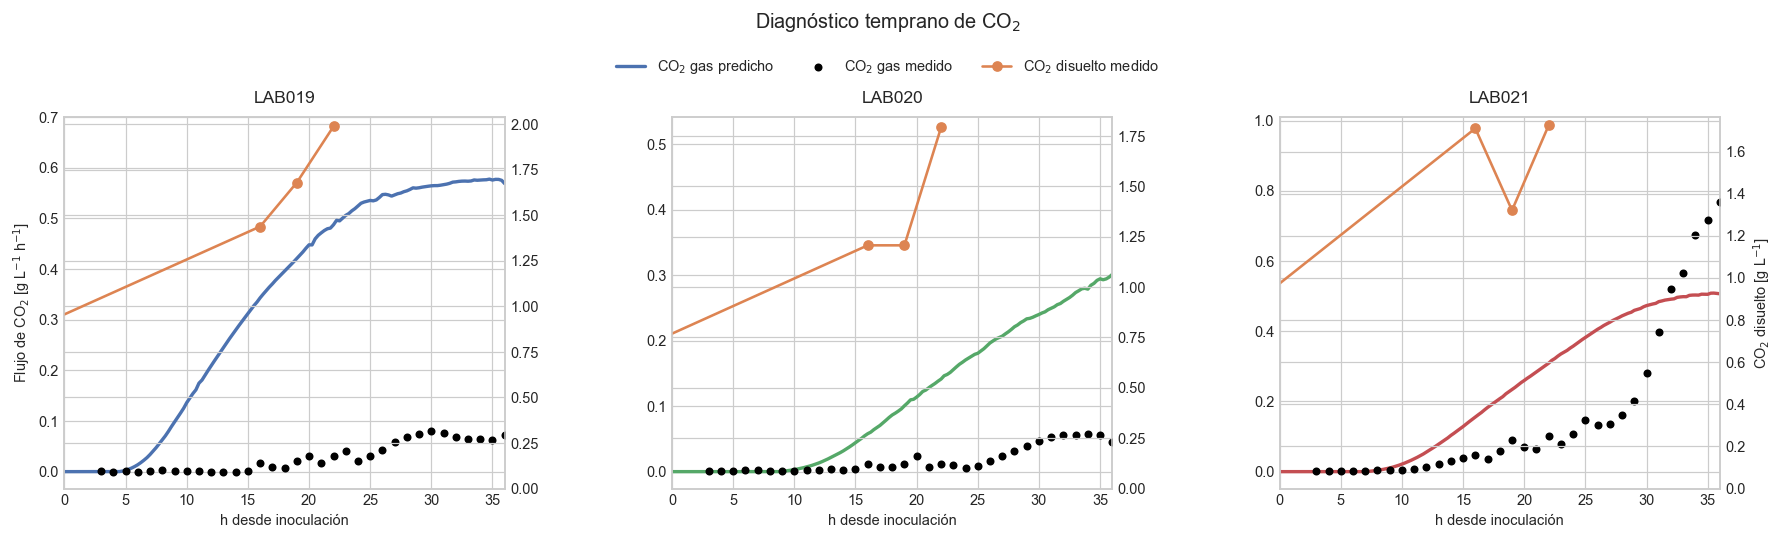

In [15]:
def integrate_to(t, y, end_h, valid=None):
    t, y = np.asarray(t, float), np.asarray(y, float)
    ok = np.isfinite(t) & np.isfinite(y) & (t >= 0) & (t <= end_h)
    if valid is not None:
        ok &= np.asarray(valid, bool)
    pairs = ok[:-1] & ok[1:] & (np.diff(t) > 0) & (np.diff(t) <= 1.5)
    return float(np.sum(0.5 * (y[:-1] + y[1:]) * np.diff(t) * pairs))


early_rows = []
for lab in LABS:
    c = chem[chem["lab"].eq(lab)].set_index("sample")
    d = dissolved[dissolved["lab"].eq(lab)].set_index("muestra")
    observed_gas = co2_hourly[co2_hourly["lab"].eq(lab)].sort_values("t_h")
    predicted_gas = co2_predictions[("primary_end_to_end", lab)]
    baseline_dissolved = float(d.loc[1, "CO2_disuelto_g_L"])
    for sample, end_h in ((2, 16.0), (4, 22.0)):
        measured_dissolved = float(d.loc[sample, "CO2_disuelto_g_L"])
        gas_emitted = integrate_to(
            observed_gas["t_h"], observed_gas["co2_observed_g_l_h"], end_h,
            observed_gas["co2_valid"],
        )
        model_emitted = integrate_to(
            predicted_gas["t_h"], predicted_gas["co2_predicted_g_l_h"], end_h,
        )
        delta_dissolved = measured_dissolved - baseline_dissolved
        early_rows.append({
            "lab": lab, "sample": sample, "t_h": end_h,
            "GF_observed_g_l": float(c.loc[str(sample), "GF_g_l"]),
            "GF_predicted_g_l": float(np.interp(end_h, core_predictions[lab].index,
                                                 core_predictions[lab]["G"] + core_predictions[lab]["F"])),
            "YAN_observed_mg_l": float(c.loc[str(sample), "YAN_mg_l"]),
            "YAN_predicted_mg_l": float(np.interp(end_h, core_predictions[lab].index,
                                                  core_predictions[lab]["N"])) * 1000.0,
            "CO2_gas_observed_g_l_lower_bound": gas_emitted,
            "CO2_gas_predicted_g_l": model_emitted,
            "CO2_disuelto_muestra_g_l": measured_dissolved,
            "CO2_disuelto_delta_vs_m1_g_l": delta_dissolved,
            "CO2_gas_plus_delta_disuelto_g_l_proxy": gas_emitted + delta_dissolved,
            "temperature_clipped_at_20C": bool(d.loc[sample, "T_recortada_a_techo_tabla"]),
        })

early_audit = pd.DataFrame(early_rows)
early_audit.to_csv(RESULTS_DIR / "early_co2_dissolved_audit.csv", index=False)
display(early_audit.round(3))

fig, axes = plt.subplots(1, 3, figsize=(17.2, 5.2), sharex=True)
legend_handles = None
right_axes = []
for ax, lab in zip(axes, LABS):
    obs = co2_hourly[co2_hourly["lab"].eq(lab)].sort_values("t_h")
    pred = co2_predictions[("primary_end_to_end", lab)]
    d = dissolved[dissolved["lab"].eq(lab) & dissolved["muestra"].isin([1, 2, 3, 4])]
    pred_line, = ax.plot(pred["t_h"], pred["co2_predicted_g_l_h"], color=COLORS[lab], lw=2.2)
    gas_points = ax.scatter(obs.loc[obs["co2_valid"], "t_h"],
                            obs.loc[obs["co2_valid"], "co2_observed_g_l_h"],
                            color="black", s=18, zorder=3)
    ax2 = ax.twinx()
    dissolved_line, = ax2.plot(d["t_h"], d["CO2_disuelto_g_L"],
                               color="#dd8452", marker="o", lw=1.7)
    right_axes.append(ax2)
    if legend_handles is None:
        legend_handles = (pred_line, gas_points, dissolved_line)
    ax2.set_ylim(bottom=0)
    ax.set_xlim(0, 36)
    ax.set_title(lab, pad=9)
    ax.set_xlabel("h desde inoculación")
axes[0].set_ylabel(r"Flujo de CO$_2$ [g L$^{-1}$ h$^{-1}$]")
right_axes[-1].set_ylabel(r"CO$_2$ disuelto [g L$^{-1}$]")
fig.suptitle(r"Diagnóstico temprano de CO$_2$", y=0.985, fontsize=13)
fig.legend(legend_handles,
           (r"CO$_2$ gas predicho", r"CO$_2$ gas medido", r"CO$_2$ disuelto medido"),
           loc="upper center", bbox_to_anchor=(0.5, 0.925), ncol=3, frameon=False)
fig.subplots_adjust(left=0.065, right=0.94, bottom=0.15, top=0.80, wspace=0.38)
display(fig)
plt.close(fig)


## Variante diagnóstica sin calibración: kernel rise-decay transitorio

Réplica de la sección 14 del holdout LAB016–LAB018 sobre este lote. **Nada se recalibra**: `theta_full`, los 9 parámetros de la capa de CO2, los brackets de activación y las predicciones end-to-end quedan intactos (verificado por snapshots al final de la celda). Lo único que cambia es el kernel del pulso de N: en lugar de la rampa lineal permanente `f(t) = clip((t − t_p)/τ_r, 0, 1)` con `A = 0.25` y `τ_r ≈ 56.7 h` (cuasi-inerte dentro del horizonte), se superpone sobre el `qprod` efectivo de la capa congelada un bump causal normalizado a pico 1,

`k(t) = (1 − e^(−Δt/τ_rise)) · e^(−Δt/τ_decay)`,   `qprod → qprod · (1 + A·bump)`,

con las escalas del diagnóstico de LAB016–018: **A = 0.30 por pulso de 0.14 kg m⁻³, τ_rise = 2 h, τ_decay = 4 h**. El bump decae a cero, de modo que la trayectoria debe volver a la end-to-end después del pulso. Se prueban dos escalados de dosis: la realmente ejecutada (0.08 kg m⁻³ = 80 ppm YAN, usada en la curva principal) y la referencia de 0.14 kg m⁻³ del diagnóstico previo. El pool de CO2 disuelto se reintegra con una réplica exacta del release continuo congelado, verificada numéricamente contra la predicción end-to-end antes de usarla. Esto **no es una calibración**: solo prueba si la forma transitoria del kernel reproduce la reactivación post-pulso observada.

,lab,scenario,dose_kg_m3,min_prepulse_g_l_h,peak_postpulse_g_l_h,reactivation_pct,hours_to_peak_h,rmse_pulse_24h,max_dev_after_pulse24_g_l_h,n_obs_24h
0,LAB019,observado (válido),NaN,0.4880,0.6675,36.7889,6.6667,NaN,NaN,24
1,LAB019,baseline end-to-end (rampa A=0.25),0.08,0.5380,0.5502,2.2703,1.1667,0.0761,0.0000,24
2,LAB019,"swap rise-decay A=0.30, tau_r=2 h, tau_d=4 h",0.08,0.5380,0.5777,7.3819,3.4167,0.0519,0.0052,24
3,LAB019,"swap rise-decay A=0.30, tau_r=2 h, tau_d=4 h",0.14,0.5380,0.6073,12.8944,6.1667,0.0372,0.0089,24
4,LAB020,observado (válido),NaN,0.3864,0.5163,33.6149,9.3333,NaN,NaN,24
5,LAB020,baseline end-to-end (rampa A=0.25),0.08,0.3648,0.3722,2.0203,1.5833,0.1149,0.0000,24
6,LAB020,"swap rise-decay A=0.30, tau_r=2 h, tau_d=4 h",0.08,0.3648,0.3903,6.9969,5.5833,0.0983,0.0043,24
7,LAB020,"swap rise-decay A=0.30, tau_r=2 h, tau_d=4 h",0.14,0.3648,0.4120,12.9411,5.5833,0.0862,0.0075,24
8,LAB021,observado (válido),NaN,0.7025,0.9629,37.0582,5.5000,NaN,NaN,24
9,LAB021,baseline end-to-end (rampa A=0.25),0.08,0.5080,0.5080,0.0000,0.0000,0.3077,0.0000,24


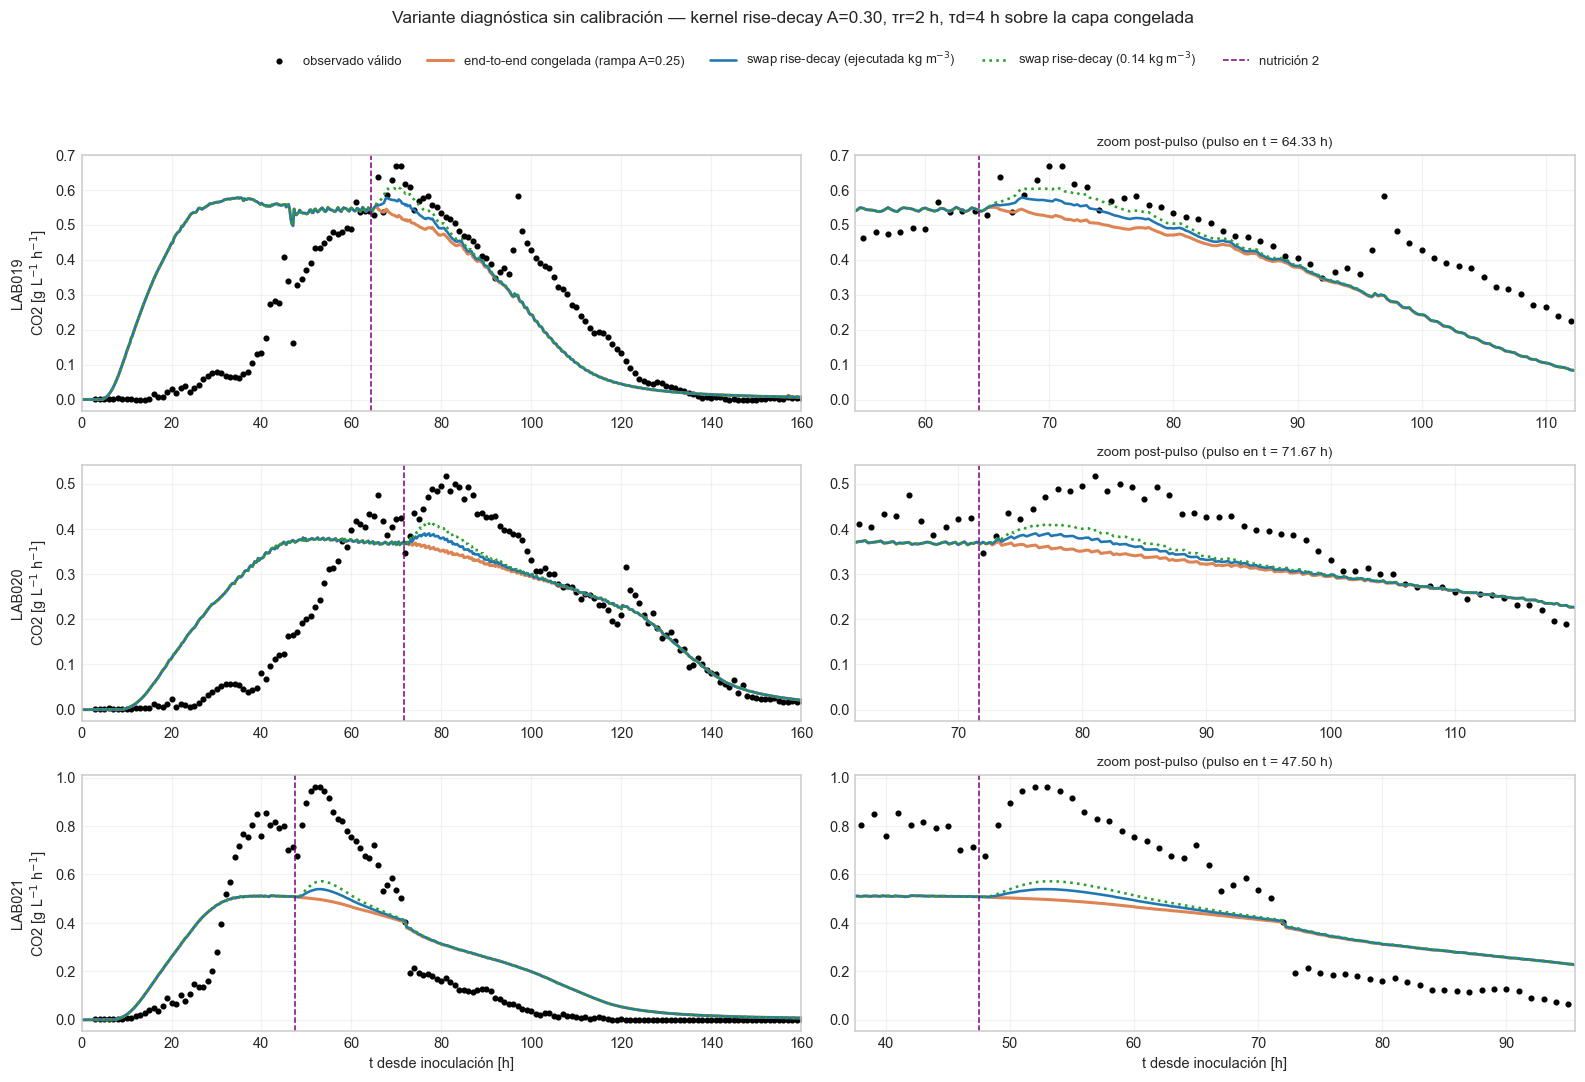

VARIANTE DIAGNÓSTICA COMPLETADA — sin ajustes; theta, capa de CO2 y predicciones end-to-end sin cambios.


In [16]:
TRANSIENT_A_BASE = 0.30          # amplitud por pulso de 0.14 kg m-3 (sección 14, lab016-018)
TRANSIENT_TAU_RISE_H = 2.0
TRANSIENT_TAU_DECAY_H = 4.0
TRANSIENT_REFERENCE_DOSE_KG_M3 = 0.14
EXECUTED_PULSE2_KG_M3 = DELTA_N_KG_M3  # dosis real ejecutada, leída del Excel

transient_snapshot = {
    "theta_full": dict(theta_full),
    "co2_params": dict(co2_params),
    "protocol_lock": dict(protocol_lock),
    "co2_predictions": {key: frame.copy(deep=True) for key, frame in co2_predictions.items()},
}


def transient_kernel(time_h, pulse_h, tau_rise_h, tau_decay_h):
    # Bump causal normalizado a pico 1 (idéntico a la sección 14 de lab016_018_natural_must_holdout).
    elapsed = np.asarray(time_h, dtype=float) - float(pulse_h)
    raw = np.zeros_like(elapsed)
    causal = elapsed >= 0.0
    dt = elapsed[causal]
    raw[causal] = (1.0 - np.exp(-dt / float(tau_rise_h))) * np.exp(-dt / float(tau_decay_h))
    peak = float(np.max(raw))
    if peak <= 0.0:
        raise RuntimeError("El kernel rise-decay no tiene soporte positivo")
    return raw / peak


def transient_pool_qgas(cache, qprod_effective):
    # Réplica exacta de la rama continuous_release de raw_qgas_grid_prediction con
    # los parámetros congelados; solo depende de qprod, csat y k_release.
    time_h = cache.time_h
    csat = float(co2_params["CO2sat_scale"]) * cache.csat_base_g_l
    k_release_h = float(co2_params["kCO2_release_h"])
    floor = co2_cross.CO2_CONTINUOUS_RELEASE_FLOOR
    dissolved = 0.0
    qgas = np.zeros(len(time_h), dtype=float)
    for idx in range(1, len(time_h)):
        dt = max(float(time_h[idx] - time_h[idx - 1]), 1e-9)
        available = dissolved / dt + max(float(qprod_effective[idx - 1]), 0.0)
        dissolved_fraction = dissolved / max(dissolved + float(csat[idx]), 1e-12)
        release_fraction = floor + (1.0 - floor) * dissolved_fraction
        qgas[idx] = min(k_release_h * dissolved * release_fraction, available)
        dissolved = max(dissolved + dt * (max(float(qprod_effective[idx - 1]), 0.0) - qgas[idx]), 0.0)
    return qgas


# Se reconstruye el cache del escenario primary_end_to_end exactamente como en la celda de la capa.
transient_caches = {}
for lab in LABS:
    observed = co2_hourly[co2_hourly["lab"].eq(lab)]
    stub = observed[["t_h"]].copy()
    stub["batch"] = lab
    stub["matrix"] = "natural"
    stub["calibratable"] = True
    stub["chemistry_last_h"] = float(observed["t_h"].max())
    caches, _diag = co2_cross.build_driver_cache({lab: holdout_batches[lab]}, {"natural": theta_full}, stub)
    core = core_predictions[lab]
    bracket = activity_bracket(core.index, core["G"] + core["F"], core["E"])
    transient_caches[lab] = replace(
        caches[lab],
        chemical_activity_lower_h=bracket["lower_h"],
        chemical_activity_upper_h=bracket["upper_h"],
        chemical_activity_center_h=bracket["center_h"],
        chemical_activity_scale_h=bracket["scale_h"],
    )

TRANSIENT_VARIANTS = (
    ("swap_rise_decay_dose_ejecutada", EXECUTED_PULSE2_KG_M3),
    ("swap_rise_decay_dose_referencia_0.14", TRANSIENT_REFERENCE_DOSE_KG_M3),
)


def transient_shape_metrics(time_h, values, pulse_h):
    time_h = np.asarray(time_h, float)
    values = np.asarray(values, float)
    support = np.isfinite(time_h) & np.isfinite(values)
    prepulse = support & (time_h >= pulse_h - 5.0) & (time_h <= pulse_h)
    postpulse = support & (time_h >= pulse_h) & (time_h <= pulse_h + 12.0)
    if not prepulse.any() or not postpulse.any():
        return {"min_prepulse_g_l_h": np.nan, "peak_postpulse_g_l_h": np.nan,
                "reactivation_pct": np.nan, "hours_to_peak_h": np.nan}
    pre_i = np.flatnonzero(prepulse)
    post_i = np.flatnonzero(postpulse)
    minimum = float(values[pre_i[np.argmin(values[pre_i])]])
    peak_i = int(post_i[np.argmax(values[post_i])])
    peak = float(values[peak_i])
    return {"min_prepulse_g_l_h": minimum, "peak_postpulse_g_l_h": peak,
            "reactivation_pct": 100.0 * (peak - minimum) / max(minimum, 1e-12),
            "hours_to_peak_h": float(time_h[peak_i] - pulse_h)}


transient_predictions = {}
transient_metric_rows = []
for lab in LABS:
    cache = transient_caches[lab]
    pulse_h = float(cache.n_pulse_time_h)
    assert np.isclose(pulse_h, PULSE2_H[lab]), (lab, pulse_h, PULSE2_H[lab])
    baseline = co2_predictions[("primary_end_to_end", lab)]
    baseline_qprod = baseline["co2_produced_g_l_h"].to_numpy(float)
    baseline_curve = baseline["co2_predicted_g_l_h"].to_numpy(float)
    # Verificación: la réplica del pool debe reproducir la capa congelada antes de tocar nada.
    qgas_replica = transient_pool_qgas(cache, baseline_qprod)
    assert np.allclose(co2_params["matrix_gain"] * qgas_replica, baseline_curve,
                       rtol=1e-10, atol=1e-12), f"{lab}: la réplica del pool no reproduce la capa congelada"

    obs = co2_hourly[co2_hourly["lab"].eq(lab) & co2_hourly["co2_valid"]].sort_values("t_h")
    window = obs["t_h"].between(pulse_h, pulse_h + 24.0)
    obs_w = obs[window]
    n_obs_w = int(len(obs_w))

    transient_metric_rows.append({
        "lab": lab, "scenario": "observado (válido)", "dose_kg_m3": np.nan,
        **transient_shape_metrics(obs["t_h"], obs["co2_observed_g_l_h"], pulse_h),
        "rmse_pulse_24h": np.nan, "max_dev_after_pulse24_g_l_h": np.nan, "n_obs_24h": n_obs_w,
    })

    pred_at_obs = np.interp(obs["t_h"], baseline["t_h"], baseline_curve)
    rmse_base = float(np.sqrt(np.mean((pred_at_obs[window] - obs_w["co2_observed_g_l_h"]) ** 2))) if n_obs_w else np.nan
    transient_metric_rows.append({
        "lab": lab, "scenario": "baseline end-to-end (rampa A=0.25)",
        "dose_kg_m3": float(cache.n_pulse_amount_kg_m3),
        **transient_shape_metrics(baseline["t_h"], baseline_curve, pulse_h),
        "rmse_pulse_24h": rmse_base, "max_dev_after_pulse24_g_l_h": 0.0, "n_obs_24h": n_obs_w,
    })

    tail_mask = np.asarray(cache.time_h, float) >= pulse_h + 24.0
    for variant, dose in TRANSIENT_VARIANTS:
        bump = (dose / TRANSIENT_REFERENCE_DOSE_KG_M3) * transient_kernel(
            cache.time_h, pulse_h, TRANSIENT_TAU_RISE_H, TRANSIENT_TAU_DECAY_H)
        qprod_variant = baseline_qprod * (1.0 + TRANSIENT_A_BASE * bump)
        curve = co2_params["matrix_gain"] * transient_pool_qgas(cache, qprod_variant)
        transient_predictions[(variant, lab)] = pd.DataFrame({
            "t_h": cache.time_h, "co2_predicted_g_l_h": curve, "bump": bump,
            "co2_produced_g_l_h": qprod_variant,
        })
        pred_at_obs = np.interp(obs["t_h"], cache.time_h, curve)
        rmse = float(np.sqrt(np.mean((pred_at_obs[window] - obs_w["co2_observed_g_l_h"]) ** 2))) if n_obs_w else np.nan
        transient_metric_rows.append({
            "lab": lab,
            "scenario": f"swap rise-decay A={TRANSIENT_A_BASE:.2f}, tau_r={TRANSIENT_TAU_RISE_H:g} h, tau_d={TRANSIENT_TAU_DECAY_H:g} h",
            "dose_kg_m3": dose,
            **transient_shape_metrics(cache.time_h, curve, pulse_h),
            "rmse_pulse_24h": rmse,
            "max_dev_after_pulse24_g_l_h": float(np.max(np.abs((curve - baseline_curve)[tail_mask]))) if tail_mask.any() else np.nan,
            "n_obs_24h": n_obs_w,
        })

transient_metrics = pd.DataFrame(transient_metric_rows)
transient_metrics.to_csv(RESULTS_DIR / "transient_kernel_diagnostic_metrics.csv", index=False)
display(transient_metrics.round(4))

fig, axes = plt.subplots(3, 2, figsize=(14.5, 9.8))
for row, lab in enumerate(LABS):
    cache = transient_caches[lab]
    pulse_h = float(cache.n_pulse_time_h)
    obs = co2_hourly[co2_hourly["lab"].eq(lab) & co2_hourly["co2_valid"]].sort_values("t_h")
    for col in (0, 1):
        ax = axes[row, col]
        ax.scatter(obs["t_h"], obs["co2_observed_g_l_h"], color="black", s=9, label="observado válido")
        baseline = co2_predictions[("primary_end_to_end", lab)]
        ax.plot(baseline["t_h"], baseline["co2_predicted_g_l_h"], color="#dd8452", lw=2.0,
                label="end-to-end congelada (rampa A=0.25)")
        for (variant, _dose), color, ls in zip(
            TRANSIENT_VARIANTS, ("tab:blue", "tab:green"), ("-", ":")
        ):
            pred = transient_predictions[(variant, lab)]
            ax.plot(pred["t_h"], pred["co2_predicted_g_l_h"], color=color, lw=1.7, ls=ls,
                    label=f"swap rise-decay ({variant.rsplit('_', 1)[-1]} kg m$^{{-3}}$)")
        ax.axvline(pulse_h, color="purple", ls="--", lw=1.0, label="nutrición 2")
        if col == 0:
            ax.set_xlim(0.0, float(baseline["t_h"].max()))
            ax.set_ylabel(f"{lab}\nCO2 [g L$^{{-1}}$ h$^{{-1}}$]")
        else:
            ax.set_xlim(pulse_h - 10.0, pulse_h + 48.0)
        ax.grid(alpha=0.25)
    axes[row, 1].set_title(f"zoom post-pulso (pulso en t = {pulse_h:.2f} h)", fontsize=9)
axes[-1, 0].set_xlabel("t desde inoculación [h]")
axes[-1, 1].set_xlabel("t desde inoculación [h]")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=5, fontsize=8.5, frameon=False, bbox_to_anchor=(0.5, 0.972))
fig.suptitle("Variante diagnóstica sin calibración — kernel rise-decay A=0.30, τr=2 h, τd=4 h sobre la capa congelada", y=0.998)
fig.tight_layout(rect=(0, 0, 1, 0.925))
display(fig)
plt.close(fig)

assert transient_snapshot["theta_full"] == theta_full
assert transient_snapshot["co2_params"] == co2_params
assert transient_snapshot["protocol_lock"] == protocol_lock
for key, frame in transient_snapshot["co2_predictions"].items():
    pd.testing.assert_frame_equal(frame, co2_predictions[key])
assert len(transient_predictions) == len(LABS) * len(TRANSIENT_VARIANTS)
print("VARIANTE DIAGNÓSTICA COMPLETADA — sin ajustes; theta, capa de CO2 y predicciones end-to-end sin cambios.")

## Verificaciones finales y lectura del resultado

In [17]:
assert protocol_lock["fit_performed"] is False
assert set(activation_table.query("scenario == 'observed_chemistry_conditioned'")["upper_h"].round(6)) == {16.0}
assert len(chem_metrics) > 0 and len(co2_metrics) > 0
assert not chem_predictions["predicted"].isna().any()
assert not co2_prediction_rows["predicted"].isna().any()

primary_co2 = co2_metrics.query("scenario == 'primary_end_to_end' and domain == 'full'")
conditioned_co2 = co2_metrics.query("scenario == 'observed_chemistry_conditioned' and domain == 'full'")
chem_full = chem_metrics[chem_metrics["domain"].eq("full")]

summary_text = f'''
### Ejecución terminada

- No se ejecutó ningún ajuste ni optimizador.
- Se evaluaron **{len(chem_predictions)}** observaciones químicas válidas posteriores a la condición inicial.
- Se evaluaron **{int(primary_co2['n'].sum())}** observaciones horarias válidas de CO2 en el escenario principal.
- El bracket observado fue `[0, 16 h]` en los tres laboratorios; sólo se usa en el diagnóstico condicionado.
- La tabla principal de química es `chemistry_metrics.csv` y la de CO2 es `co2_metrics.csv`.

El escenario `primary_end_to_end` es el resultado de holdout. El escenario `observed_chemistry_conditioned` sirve para separar error de activación/dinámica upstream de error en la capa gaseosa.
'''
display(Markdown(summary_text))
display(chem_full.pivot_table(index=["lab", "variable"], values=["MAE", "RMSE", "bias_pred_minus_obs"]).round(4))
display(primary_co2[["lab", "RMSE_g_l_h", "onset_observed_h", "onset_predicted_h", "peak_observed_g_l_h", "peak_predicted_g_l_h", "AUC_observed_g_l", "AUC_predicted_g_l"]].round(4))
print("Notebook completed; optimization performed:", False)


### Ejecución terminada

- No se ejecutó ningún ajuste ni optimizador.
- Se evaluaron **247** observaciones químicas válidas posteriores a la condición inicial.
- Se evaluaron **474** observaciones horarias válidas de CO2 en el escenario principal.
- El bracket observado fue `[0, 16 h]` en los tres laboratorios; sólo se usa en el diagnóstico condicionado.
- La tabla principal de química es `chemistry_metrics.csv` y la de CO2 es `co2_metrics.csv`.

El escenario `primary_end_to_end` es el resultado de holdout. El escenario `observed_chemistry_conditioned` sirve para separar error de activación/dinámica upstream de error en la capa gaseosa.


MAE      RMSE  bias_pred_minus_obs
lab    variable                                         
LAB019 AcAld     123.4502  140.9946            -123.4502
       Acetate     0.0672    0.0963              -0.0005
       E          19.2073   21.3226              19.2073
       F          13.1011   15.4567             -13.1011
       G          14.7587   15.2420             -14.7587
       GF         33.8580   35.9008             -33.8580
       Gly         1.2854    1.3148               1.2854
       N           0.1013    0.1208              -0.1013
       Pyr        36.0774   44.5984             -36.0740
LAB020 AcAld     138.5081  154.4202            -138.5081
       Acetate     0.0622    0.0762              -0.0087
       E           8.4418    8.8127               8.4418
       F           7.4088    8.0190              -3.7338
       G           6.0242    6.7680              -6.0242
       GF         11.7084   14.0000             -10.6444
       Gly         0.7000    0.7412               0.7000
       N           0.0812    0.0949              -0.0812
       Pyr        35.3899   41.8264             -35.3899
LAB021 AcAld     103.3870  121.4694            -103.3870
       Acetate     0.0594    0.0842              -0.0184
       E           3.7302    4.0173               1.9125
       F           5.4794    5.8637               5.4794
       G           6.9711    8.1304               4.8915
       GF          5.8770    9.3344               5.8573
       Gly         0.2893    0.3771               0.2287
       N           0.0431    0.0539              -0.0431
       Pyr        32.0398   40.2718             -32.0398

,lab,RMSE_g_l_h,onset_observed_h,onset_predicted_h,peak_observed_g_l_h,peak_predicted_g_l_h,AUC_observed_g_l,AUC_predicted_g_l
2,LAB019,0.2159,28.0,9.0,0.6675,0.5760,35.4756,45.9851
8,LAB020,0.1099,32.0,16.0,0.5163,0.3796,31.6971,35.7229
14,LAB021,0.1774,24.0,14.0,0.9629,0.5122,36.2936,36.4813


Notebook completed; optimization performed: False
